# Trabajo Práctico 1

## Modelo predictivo de tarifas de Uber

### Facultad de Ciencias Exactas, Ingenieria y Agrimensura (FCEIA) - Universidad Nacional de Rosario (UNR)

**Integrantes:**
| Nombre | Legajo |
|----------|-------|
| Bollini, Lorenzo | B-6729/6 |
| Chiappe, Maximiliano | C-7542/6 |
| Lenarduzzi, Juan | L-3398/7 |
---

### Contenidos

1. Configuración del entorno
2. Carga e Inspección Estructural del Dataset
3. Análisis Descriptivo 
4. Regresión Lineal
5. Optimización de Hiperparámetros
6. Comparación de Modelos
7. Conclusiones

---

## Configuración del entorno



In [208]:
# ── Librerías generales ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: preprocesamiento ───────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline

# ── Scikit-learn: modelos ────────────────────────────────────────────
from sklearn.linear_model import (LinearRegression, LogisticRegression,
                                   Ridge, Lasso, ElasticNet,
                                   RidgeCV, LassoCV, ElasticNetCV,
                                   SGDRegressor)

# ── Scikit-learn: métricas ───────────────────────────────────────────
from sklearn.metrics import (r2_score, mean_squared_error,
                              mean_absolute_error,
                              mean_absolute_percentage_error,
                              accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              roc_curve, auc, precision_recall_curve,
                              f1_score)
from sklearn import metrics

# ── Scipy ────────────────────────────────────────────────────────────
from scipy import stats

# Configuracion global de visualizacion
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='viridis')

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 2.2.2
numpy: 2.0.2


---

## Carga e Inspeccion Estructural del Dataset

### Sobre el dataset uber_fares


| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `key` | Nominal | ID de cada viaje. |
| `fare_amount` | Continua | El costo de cada viaje en USD. |
| `pickup_datetime` | String | Fecha y hora en que se activó el taxímetro. |
| `passenger_count` | Discreta |  el  número  de  pasajeros  en  el  vehículo  (valor  ingresado  por el conductor). |
| `pickup_longitude` | Continua | La longitud donde se activó el  taxímetro. |
| `pickup_latitude` | Continua | La latitud donde se activó el  taxímetro. |
| `dropoff_longitude` | Continua | La longitud donde se desactivó el  taxímetro. |
| `dropoff_latitude` | Continua | La latitud donde se desactivó el  taxímetro. |

In [209]:
!gdown '1u11-fxlSN5oipXJ37-wo-q9lqY6Cd8pS'

Downloading...
From: https://drive.google.com/uc?id=1u11-fxlSN5oipXJ37-wo-q9lqY6Cd8pS
To: /content/uber_fares.csv
100% 21.6M/21.6M [00:00<00:00, 79.3MB/s]


In [210]:
df = pd.read_csv('uber_fares.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB') # Esto les va a servir cuando tengan un dataset muy pesado :)
print()
df.head(5)

Dimensiones del dataset: 200000 filas x 9 columnas
Memoria utilizada: 39.20 MB



,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.4700,2015-05-07 19:50:00 UTC,-73.9998,40.7384,-73.9995,40.7232,1
1,27835199,2009-07-17 20:00:04,7.6000,2009-07-17 20:00:04 UTC,-73.9944,40.7282,-73.9947,40.7503,1
2,44984355,2009-08-24 21:49:07,12.6500,2009-08-24 21:49:07 UTC,-74.0050,40.7408,-73.9626,40.7726,1
3,25894730,2009-06-26 08:17:45,5.0100,2009-06-26 08:17:45 UTC,-73.9761,40.7908,-73.9653,40.8033,3
4,17610152,2014-08-28 17:46:18,15.6400,2014-08-28 17:46:18 UTC,-73.9250,40.7441,-73.9731,40.7612,5


In [211]:
# Inspección de tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


---

## Analisis Descriptivo

---
### Feature Engineering

---
#### Distancias (Manhattan)

In [212]:
# 1. Definimos la función Manhattan (ultra rápida)
def distancia_manhattan(lat1, lon1, lat2, lon2):
    # Calculamos la diferencia absoluta entre las coordenadas
    diferencia_lat = np.abs(lat2 - lat1)
    diferencia_lon = np.abs(lon2 - lon1)

    return (diferencia_lat + diferencia_lon) * 111.0


df['distance_km'] = distancia_manhattan(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

Se optó por usar Manhattan en vez de Haversine por la estructura de una ciudad. Este método hace el cálculo de las distancias más realista, ya que representa el movimiento por bloques y no con la distancia lineal.

In [213]:
print(df['distance_km'].describe())

count   199999.0000
mean        36.5159
std       1290.6876
min          0.0000
25%          1.7608
50%          3.0744
75%          5.5866
max     362987.2924
Name: distance_km, dtype: float64


---
#### Fechas

In [214]:
# Convertir el texto a formato datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Nuevas columnas con información de las fechas
df['hora_del_dia'] = df['pickup_datetime'].dt.hour
df['dia_semana'] = df['pickup_datetime'].dt.dayofweek
df['es_fin_de_semana'] = df['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                200000 non-null  int64              
 1   date               200000 non-null  object             
 2   fare_amount        200000 non-null  float64            
 3   pickup_datetime    200000 non-null  datetime64[ns, UTC]
 4   pickup_longitude   200000 non-null  float64            
 5   pickup_latitude    200000 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    200000 non-null  int64              
 9   distance_km        199999 non-null  float64            
 10  hora_del_dia       200000 non-null  int32              
 11  dia_semana         200000 non-null  int32              
 12  es_fin_de_semana   200000 non-

In [216]:
df.head(3)

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,hora_del_dia,dia_semana,es_fin_de_semana
0,24238194,2015-05-07 19:50:00,8.4700,2015-05-07 19:50:00+00:00,-73.9998,40.7384,-73.9995,40.7232,1,1.7141,19,3,0
1,27835199,2009-07-17 20:00:04,7.6000,2009-07-17 20:00:04+00:00,-73.9944,40.7282,-73.9947,40.7503,1,2.4925,20,4,0
2,44984355,2009-08-24 21:49:07,12.6500,2009-08-24 21:49:07+00:00,-74.0050,40.7408,-73.9626,40.7726,1,8.2534,21,0,0


---
#### Eliminar Columnas

In [217]:
cols_drop = ['key', 'date', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude']
df = df.drop(columns = cols_drop)
df.columns

Index(['fare_amount', 'passenger_count', 'distance_km', 'hora_del_dia',
       'dia_semana', 'es_fin_de_semana'],
      dtype='object')

---
### División Train-Test

In [218]:
# Selección de variables predictoras
X = df[['distance_km', 'passenger_count', 'hora_del_dia', 'dia_semana', 'es_fin_de_semana']]
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")

Set de entrenamiento: (160000, 5)
Set de prueba: (40000, 5)


---
### Limpieza en Conjunto de Entrenamiento

In [219]:
train_completo = X_train.copy()
train_completo['fare_amount'] = y_train

In [220]:
train_completo.head(4)

,distance_km,passenger_count,hora_del_dia,dia_semana,es_fin_de_semana,fare_amount
153248,4.2449,1,21,3,0,11.5900
67802,21.1216,1,22,2,0,33.7200
148889,1.7760,1,8,6,1,7.0700
103093,0.5678,2,23,5,1,16.2000


In [221]:
train_completo = train_completo.reset_index()
train_completo = train_completo.drop(columns='index')
train_completo.head(4)

,distance_km,passenger_count,hora_del_dia,dia_semana,es_fin_de_semana,fare_amount
0,4.2449,1,21,3,0,11.5900
1,21.1216,1,22,2,0,33.7200
2,1.7760,1,8,6,1,7.0700
3,0.5678,2,23,5,1,16.2000


---
#### Nulos

In [222]:
print('------Nulos por columna------')
train_completo.isnull().sum()

------Nulos por columna------


,0
distance_km,1
passenger_count,0
hora_del_dia,0
dia_semana,0
es_fin_de_semana,0
fare_amount,0


In [223]:
train_completo.dropna(inplace=True)
train_completo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159999 entries, 0 to 159999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance_km       159999 non-null  float64
 1   passenger_count   159999 non-null  int64  
 2   hora_del_dia      159999 non-null  int32  
 3   dia_semana        159999 non-null  int32  
 4   es_fin_de_semana  159999 non-null  int64  
 5   fare_amount       159999 non-null  float64
dtypes: float64(2), int32(2), int64(2)
memory usage: 7.3 MB


Tras realizar el conteo de datos faltantes, se detectó un único registro con valores nulos en la columna de distancias. Se decidió eliminarlo dada la representatividad de este único registro sobre el total de la muestra.

---
#### Registros Duplicados

In [224]:
train_completo.duplicated().sum()

np.int64(19)

In [225]:
train_completo = train_completo.drop_duplicates()
len(train_completo)

159980

Se decidió eliminar los duplicados debido a la baja representatividad sobre el dataset completo.

---
### Valores Atípicos

In [226]:
print('------Medidas de variables numéricas------')
train_completo.describe()

------Medidas de variables numéricas------


,distance_km,passenger_count,hora_del_dia,dia_semana,es_fin_de_semana,fare_amount
count,159980.0000,159980.0000,159980.0000,159980.0000,159980.0000,159980.0000
mean,36.5925,1.6850,13.4838,3.0493,0.2836,11.3555
std,1384.0690,1.4057,6.5129,1.9475,0.4508,9.8346
min,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
25%,1.7640,1.0000,9.0000,1.0000,0.0000,5.9800
50%,3.0816,1.0000,14.0000,3.0000,0.0000,8.4300
75%,5.5904,2.0000,19.0000,5.0000,1.0000,12.6700
max,362987.2924,208.0000,23.0000,6.0000,1.0000,324.4100


---
#### Cantidad de Pasajeros

En la columna 'passenger_count' se ve un valor máximo de 208, se decidió eliminar esa fila, y situar el límite de pasajeros, en 6 por la posibilidad de viajes en vehículos grandes con dicha capacidad (UberXL).

In [227]:
# Passenger Count
pasajeros = train_completo[train_completo['passenger_count'] > 6]
print(f'Cantidad de registros con más de 6 pasajeros: {len(pasajeros)}')

# Se elimina ese único registro (208 pasajeros)
train_completo = train_completo[train_completo['passenger_count'] <= 6]

# Verificación
print('-'*50)
train_completo.describe()

Cantidad de registros con más de 6 pasajeros: 1
--------------------------------------------------


,distance_km,passenger_count,hora_del_dia,dia_semana,es_fin_de_semana,fare_amount
count,159979.0000,159979.0000,159979.0000,159979.0000,159979.0000,159979.0000
mean,36.5927,1.6838,13.4839,3.0494,0.2836,11.3555
std,1384.0733,1.3077,6.5129,1.9475,0.4508,9.8347
min,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
25%,1.7640,1.0000,9.0000,1.0000,0.0000,5.9800
50%,3.0816,1.0000,14.0000,3.0000,0.0000,8.4300
75%,5.5904,2.0000,19.0000,5.0000,1.0000,12.6700
max,362987.2924,6.0000,23.0000,6.0000,1.0000,324.4100


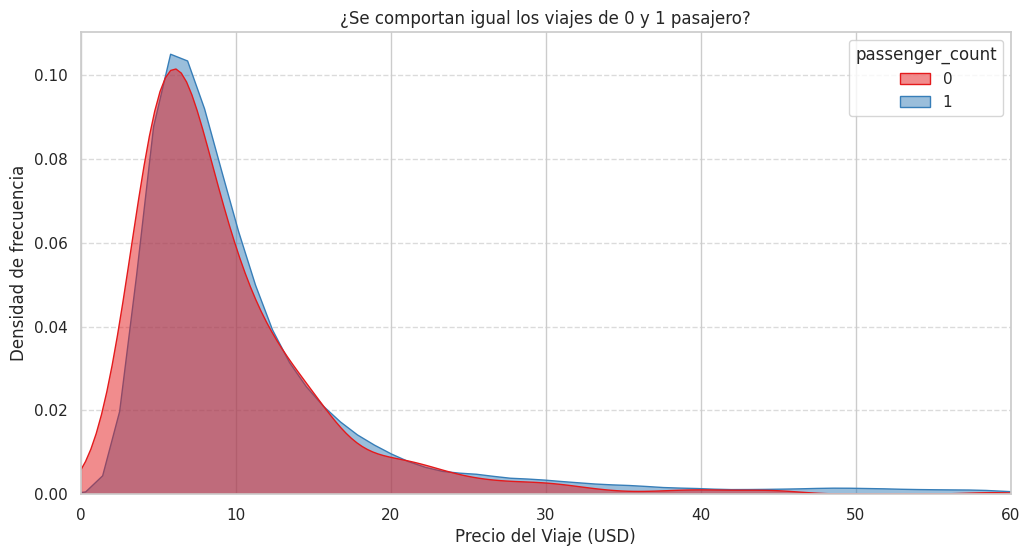

In [228]:
# DataFrame auxiliar solo con 0 y 1 pasajero para comparar
df_comparacion = train_completo[train_completo['passenger_count'].isin([0, 1])]

# Gráficos de las densidades
plt.figure(figsize=(12, 6))

# Usamos common_norm=False para que las áreas se ajusten a su propia escala
# (porque hay muchos más viajes de 1 pasajero que de 0)
sns.kdeplot(data=df_comparacion, x='fare_amount', hue='passenger_count',
            fill=True, common_norm=False, palette='Set1', alpha=0.5)

plt.title('¿Se comportan igual los viajes de 0 y 1 pasajero?')
plt.xlabel('Precio del Viaje (USD)')
plt.ylabel('Densidad de frecuencia')
plt.xlim(0, 60) # Recortamos en 60 para ver bien el grueso de los viajes
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

El comportamiento de los precios con 1 o ningún pasajero tienen un comportamiento similar, teniendo en cuenta esto y la posibilidad de que los viajes con 0 pasajeros se refieran a envíos, se toman como registros válidos.

---
#### Distancias

In [229]:
train_completo['distance_km'].describe()

,distance_km
count,159979.0000
mean,36.5927
std,1384.0733
min,0.0000
25%,1.7640
50%,3.0816
75%,5.5904
max,362987.2924


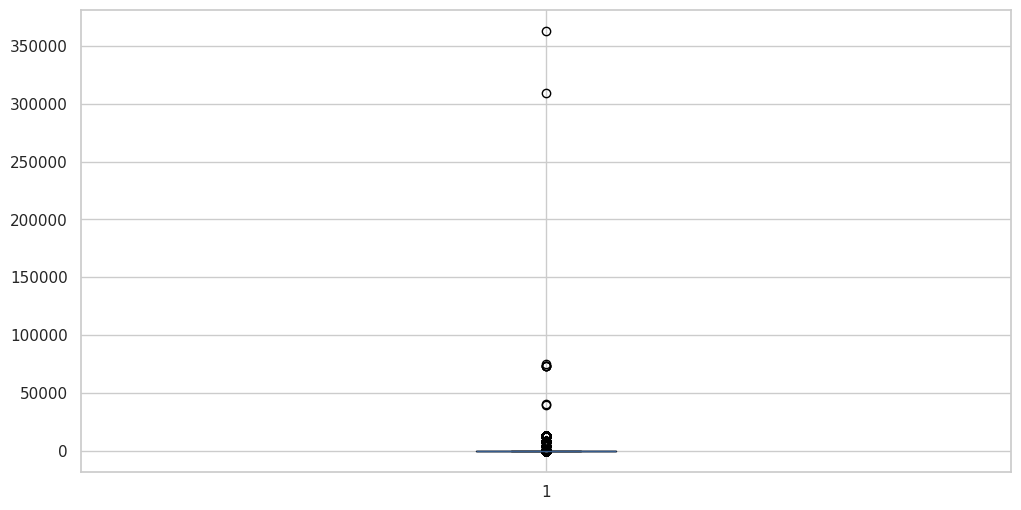

In [230]:
plt.figure()
plt.boxplot(data=train_completo, x = 'distance_km')
plt.show()

In [231]:
# Contamos los viajes basura (distancia menor a 0.5 km O mayor a 100 km)
print('Viajes con distancia 0 distancia menor a 0.5 km o mayor a 100 km:',
      len(train_completo[(train_completo['distance_km'] < 0.5) | (train_completo['distance_km'] > 100)]))

# Filtramos para quedarnos solo con los buenos (distancia mayor a 0 Y menor o igual a 100)
train_completo = train_completo[(train_completo['distance_km'] >= 0.5) & (train_completo['distance_km'] <= 100)]

Viajes con distancia 0 distancia menor a 0.5 km o mayor a 100 km: 7390


In [232]:
train_completo['distance_km'].describe()

,distance_km
count,152589.0000
mean,5.0121
std,5.6111
min,0.5001
25%,1.9121
50%,3.2168
75%,5.7522
max,98.3191


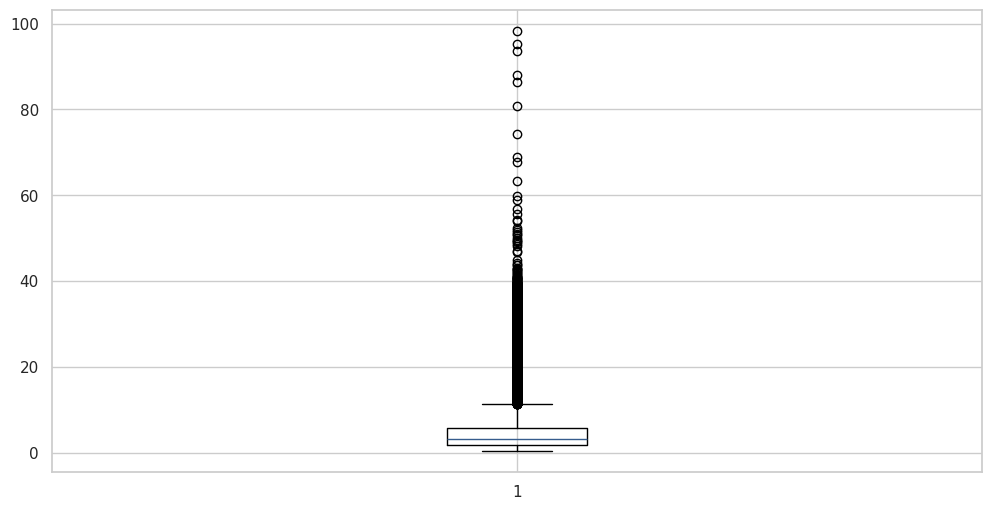

In [233]:
plt.figure()
plt.boxplot(data=train_completo, x = 'distance_km')
plt.show()

Se decidió eliminar los viajes menores a 0.5 km tomándolos como errores. Los mayores a 100 se eliminaron ya que son casos excepcionales que podrían afectar luego al modelo.

---
#### Precios

In [234]:
train_completo['fare_amount'].describe()

,fare_amount
count,152589.0000
mean,11.3713
std,9.5367
min,1.0000
25%,6.0600
50%,8.5000
75%,12.7200
max,227.8100


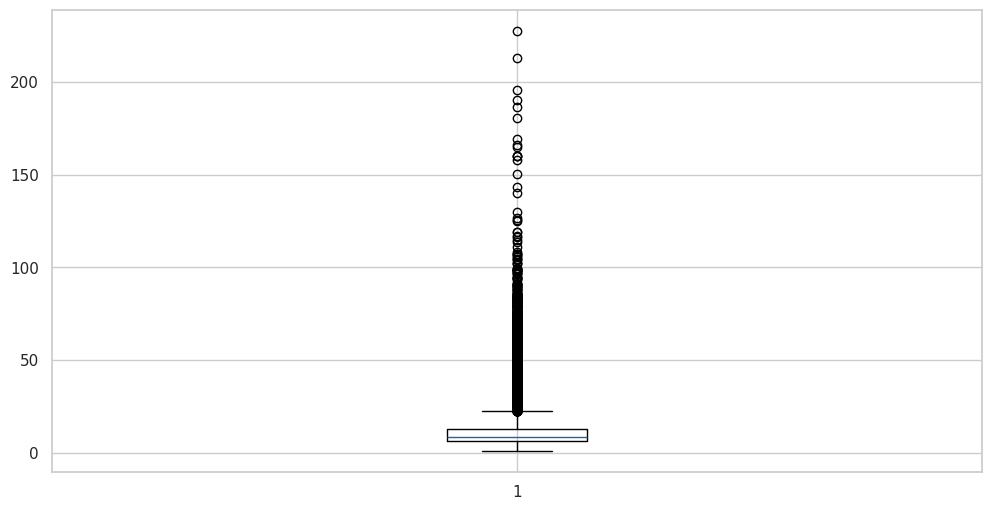

In [235]:
plt.figure()
plt.boxplot(data=train_completo, x = 'fare_amount')
plt.show()

Se decidió no eliminar registros por precio ya que antes se filtró por distancias, entonces se consideran válidos todos los registros restantes.

---
### Visualización de Variables

---
#### Histogramas de Variables Numéricas Continuas

In [236]:
var_continuas = ['fare_amount', 'distance_km']

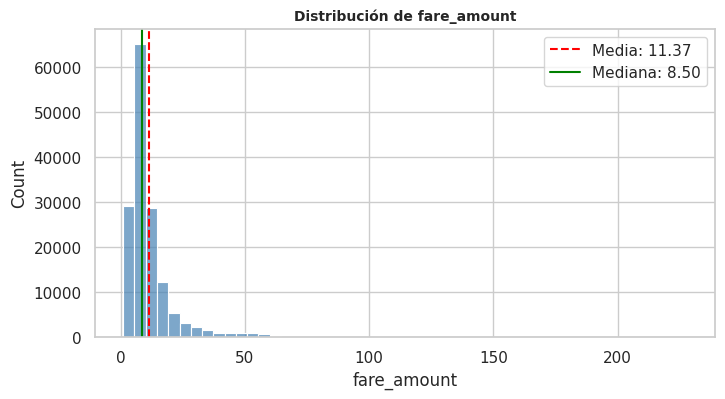

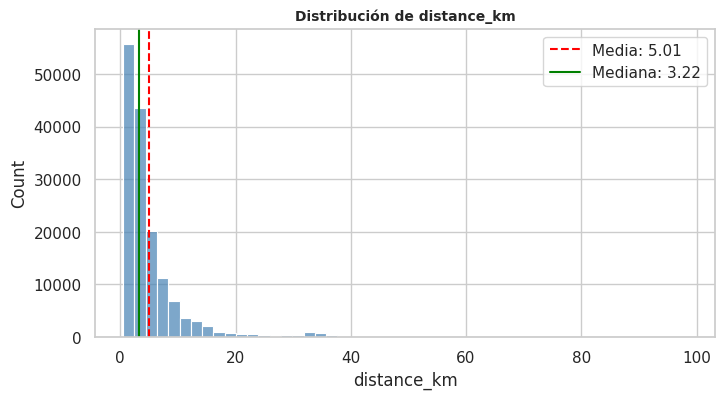

In [237]:
for col in var_continuas:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_completo[col], kde=False, bins=50, color='steelblue', edgecolor='white', alpha=0.7)

    media = train_completo[col].mean()
    mediana = train_completo[col].median()
    plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')

    plt.title(f'Distribución de {col}', fontweight='bold', fontsize=10)
    plt.legend()
    plt.show()

En los histogramas de precio y distancia, se ve una distribución asimétrica a la derecha, lo que muestra una concentración en valores chicos.

---
#### Distribución de Variables Discretas y Categóricas

In [238]:
disc_categ = ['passenger_count', 'dia_semana', 'es_fin_de_semana', 'hora_del_dia']

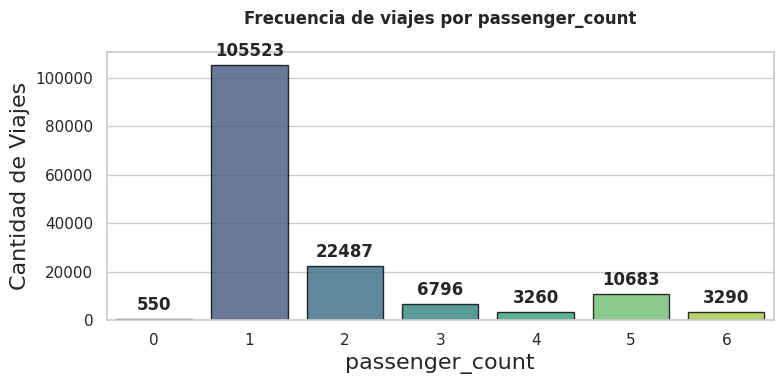

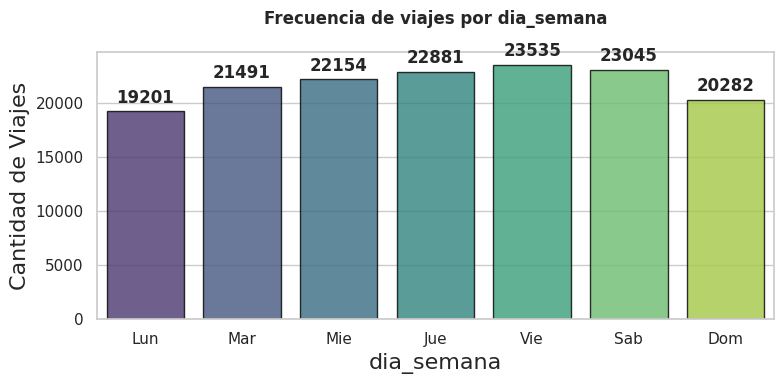

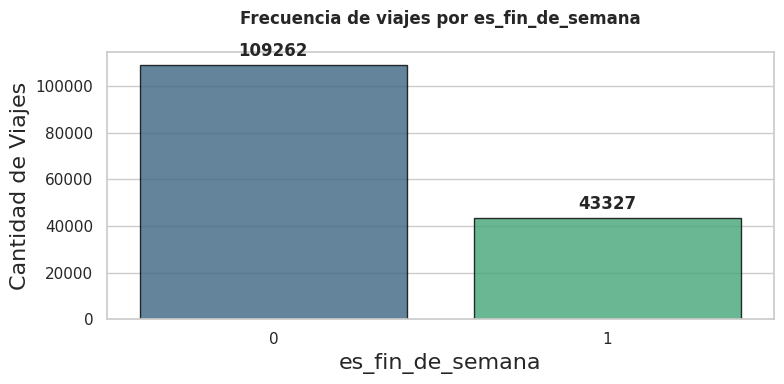

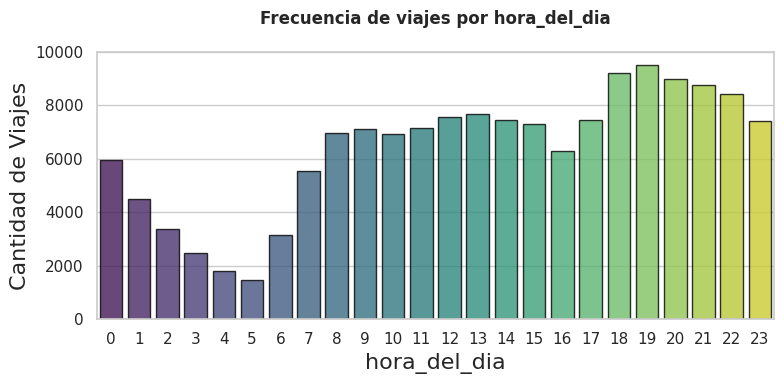

In [239]:
for col in disc_categ:
    plt.figure(figsize=(8, 4))

    # Creamos el gráfico de barras
    ax = sns.countplot(data=train_completo, x=col, palette='viridis', edgecolor='black', alpha=0.8)

    # Personalización de títulos
    plt.title(f'Frecuencia de viajes por {col}', fontweight='bold', fontsize=12, pad=20)
    plt.xlabel(col, fontsize=16)
    plt.ylabel('Cantidad de Viajes', fontsize=16)

    # Si es el día de la semana, le ponemos los nombres para que quede más pro
    if col == 'dia_semana':
        ax.set_xticklabels(['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom'])

    # Agregamos los números arriba de cada barra
    if col == 'hora_del_dia':
        pass
    else:
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 10),
                        textcoords='offset points',
                        fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

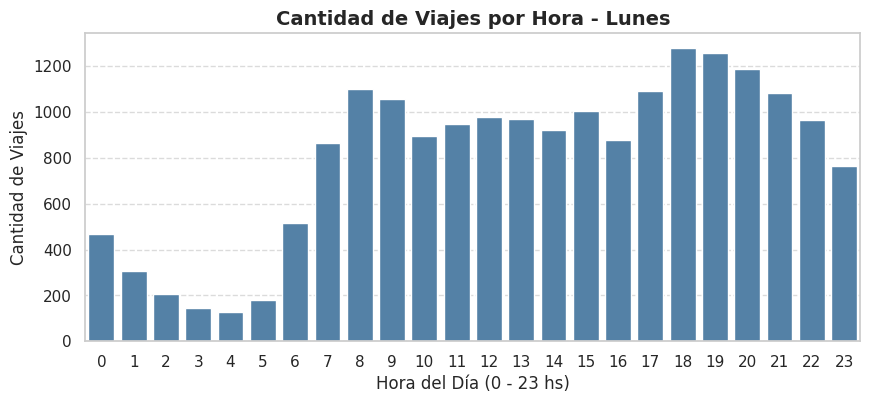

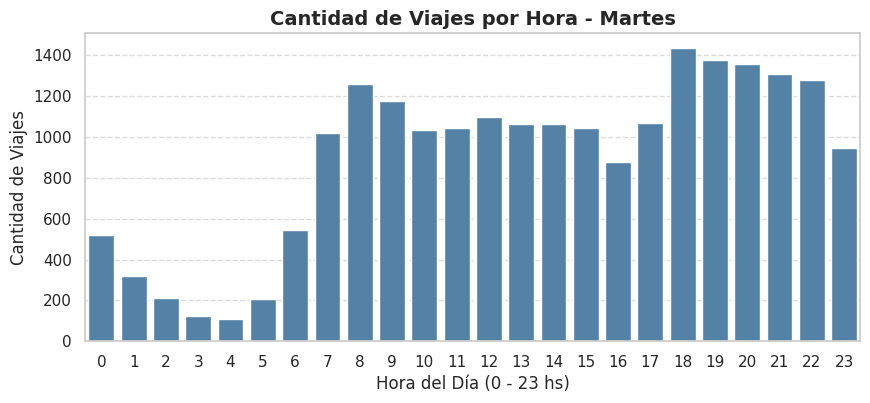

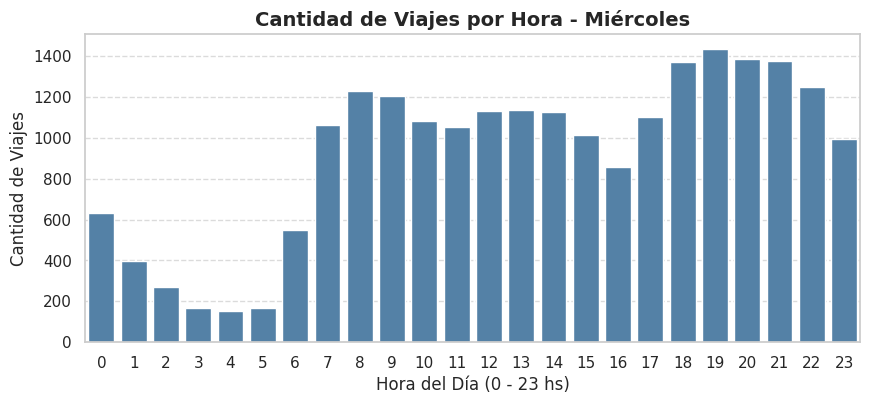

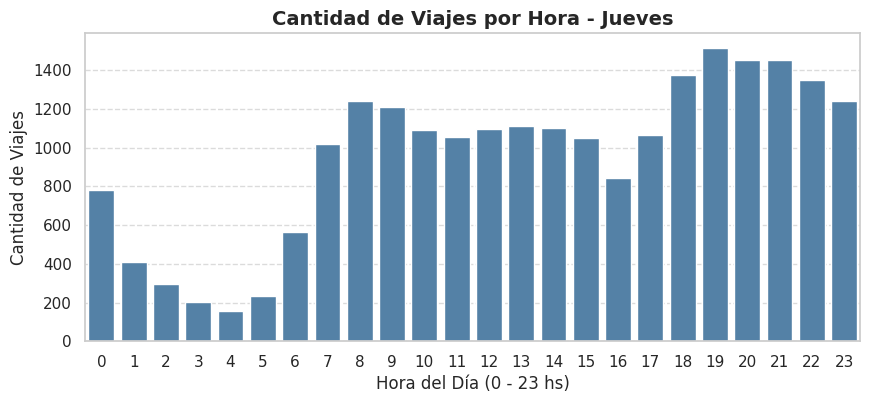

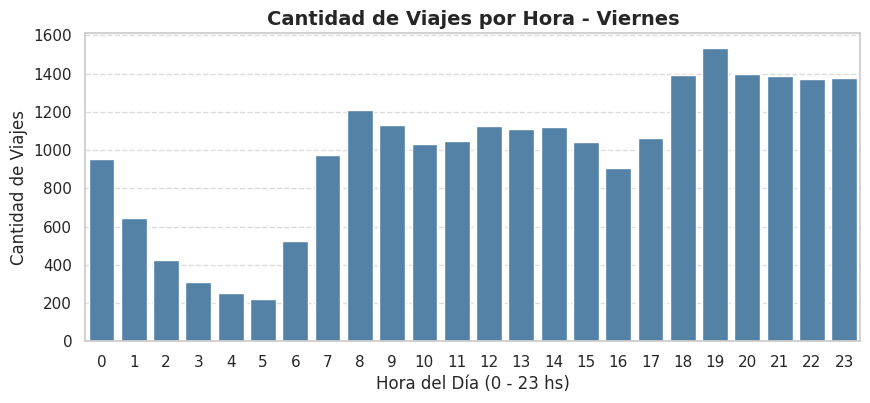

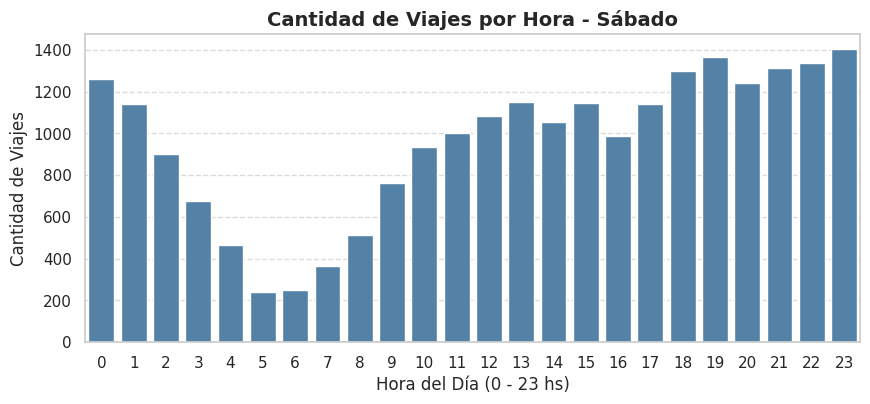

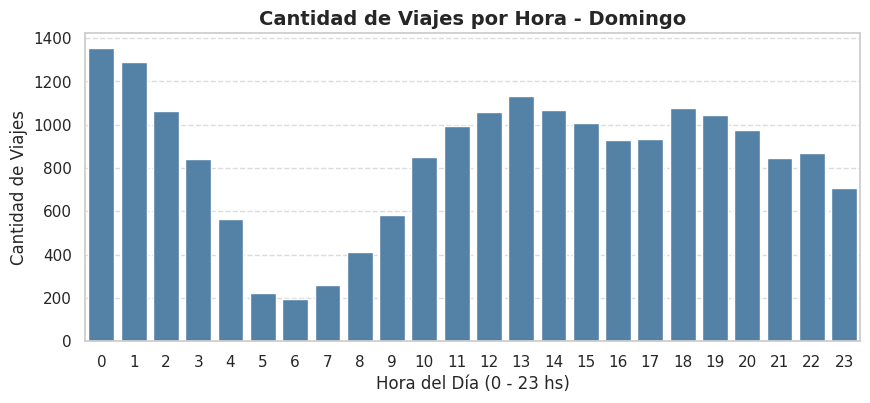

In [240]:
dias = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}

for num_dia, nombre_dia in dias.items():

    #  Filtramos la tabla para quedarnos solo con los viajes de ese dia
    datos_dia = train_completo[train_completo['dia_semana'] == num_dia]

    # Contamos cuántos viajes hubo en cada hora (y ordenamos de 0 a 23)
    viajes_por_hora = datos_dia['hora_del_dia'].value_counts().sort_index()

    #  Armamos un lienzo nuevo en cada vuelta
    plt.figure(figsize=(10, 4))
    sns.barplot(x=viajes_por_hora.index, y=viajes_por_hora.values, color='steelblue')

    plt.title(f'Cantidad de Viajes por Hora - {nombre_dia}', fontsize=14, fontweight='bold')
    plt.xlabel('Hora del Día (0 - 23 hs)')
    plt.ylabel('Cantidad de Viajes')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

---
#### ScatterPlot Precio vs. Distancia

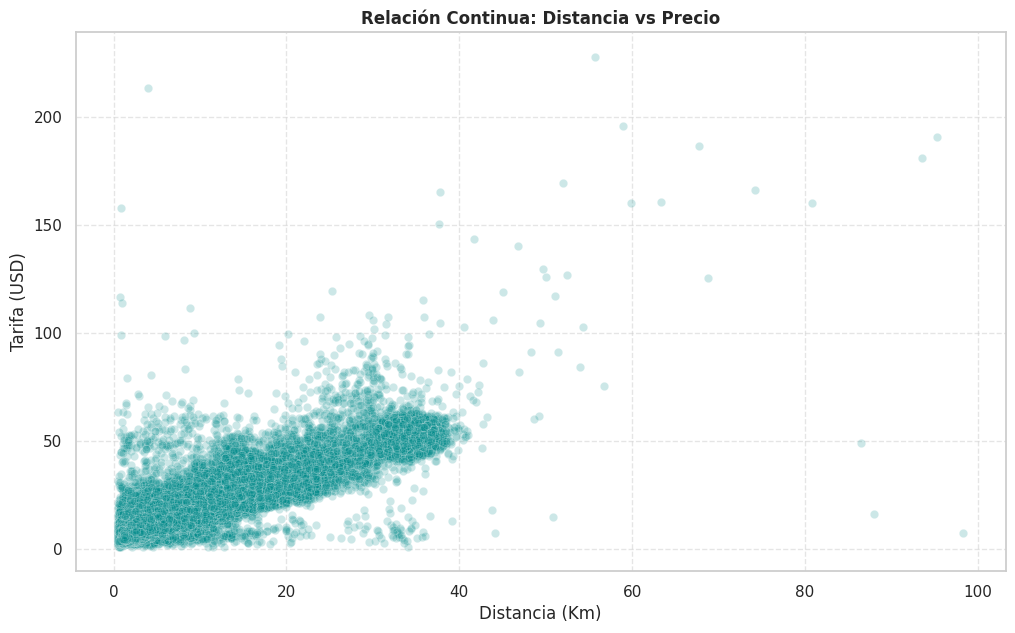

In [241]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=train_completo, x='distance_km', y='fare_amount', alpha=0.2, color='darkcyan')
plt.title('Relación Continua: Distancia vs Precio', fontweight='bold')
plt.xlabel('Distancia (Km)')
plt.ylabel('Tarifa (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

En este gráfico se observa la correlación entre la distancia y el precio, mostrando una relación lineal positiva entre ambas variables.

---
### Matriz de Correlación

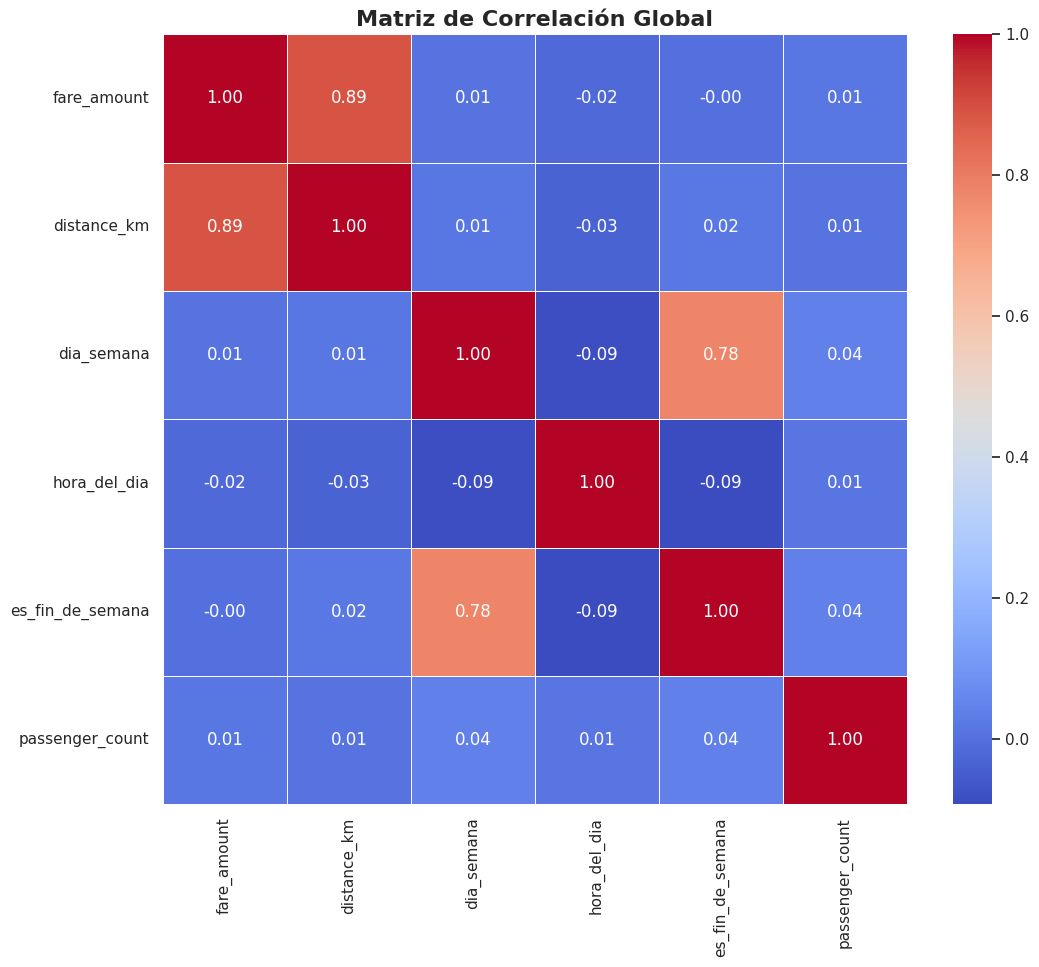

In [242]:
# Calculamos la correlación de todas las variables numéricas
var_corr = ['fare_amount', 'distance_km', 'dia_semana', 'hora_del_dia', 'es_fin_de_semana', 'passenger_count']
corr = train_completo[var_corr].corr()

# Creamos el heatmeap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación Global', fontweight='bold', fontsize=16)
plt.show()

---
### Limpieza de Datos de Test

In [243]:
test_completo = X_test.copy()
test_completo['fare_amount'] = y_test

In [244]:
test_completo = test_completo.reset_index()
test_completo = test_completo.drop(columns='index')
test_completo.head(4)

,distance_km,passenger_count,hora_del_dia,dia_semana,es_fin_de_semana,fare_amount
0,1.3967,1,23,0,0,5.4300
1,0.0000,5,21,6,1,49.3200
2,3.2924,5,18,3,0,4.9600
3,12.9671,3,20,2,0,33.2300


In [245]:
test_completo.describe()

,distance_km,passenger_count,hora_del_dia,dia_semana,es_fin_de_semana,fare_amount
count,40000.0000,40000.0000,40000.0000,40000.0000,40000.0000,40000.0000
mean,36.2267,1.6827,13.5263,3.0440,0.2826,11.3950
std,817.1437,1.3043,6.5151,1.9449,0.4503,10.3678
min,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
25%,1.7510,1.0000,9.0000,1.0000,0.0000,5.9400
50%,3.0476,1.0000,14.0000,3.0000,0.0000,8.4000
75%,5.5726,2.0000,19.0000,5.0000,1.0000,12.6600
max,77097.3549,6.0000,23.0000,6.0000,1.0000,503.1300


In [246]:
test_completo.isna().sum()

,0
distance_km,0
passenger_count,0
hora_del_dia,0
dia_semana,0
es_fin_de_semana,0
fare_amount,0


---
#### Distancias

In [247]:
print('Registros en test con distancia menor a 0.5 o mayor a 100km:', len(test_completo[(test_completo['distance_km'] < 0.5) | (test_completo['distance_km'] > 100)]))
test_completo = test_completo[(test_completo['distance_km'] >= 0.5) & (test_completo['distance_km'] <= 100)]


Registros en test con distancia menor a 0.5 o mayor a 100km: 1935


In [248]:
test_completo.describe()

,distance_km,passenger_count,hora_del_dia,dia_semana,es_fin_de_semana,fare_amount
count,38065.0000,38065.0000,38065.0000,38065.0000,38065.0000,38065.0000
mean,5.0012,1.6847,13.5298,3.0430,0.2821,11.3689
std,5.5990,1.3047,6.5170,1.9430,0.4500,9.6018
min,0.5001,0.0000,0.0000,0.0000,0.0000,1.0000
25%,1.9040,1.0000,9.0000,1.0000,0.0000,6.0300
50%,3.1884,1.0000,14.0000,3.0000,0.0000,8.4600
75%,5.7586,2.0000,19.0000,5.0000,1.0000,12.7000
max,57.9905,6.0000,23.0000,6.0000,1.0000,151.3900


Se eligió limpiar los datos de test, porque si bien implica fuga de datos, los outliers afectaban a las métricas de regresión lineal.

---
### Escalado de Datos

In [249]:
# Convertimos el día de la semana en variables dummy con one hot encoding
train_completo = pd.get_dummies(train_completo, columns=['dia_semana'], drop_first=True, dtype=int)
test_completo = pd.get_dummies(test_completo, columns=['dia_semana'], drop_first=True, dtype=int)

# 2. Separamos X e y. Además, eliminamos 'es_fin_de_semana' para evitar multicolinealidad
# ya que esa información ya esta
X_train_limpio = train_completo.drop(columns=['fare_amount', 'es_fin_de_semana'])
y_train_limpio = train_completo['fare_amount']

X_test_limpio = test_completo.drop(columns=['fare_amount', 'es_fin_de_semana'])
y_test_limpio = test_completo['fare_amount']

In [250]:
### Transformaciones con fit_transform y transform
# Ejemplo con StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_limpio)
X_test_scaled = scaler.transform(X_test_limpio)

print("Antes del escalado:")
print(X_train_limpio.head())
print("Después del escalado:")
print(X_train_scaled[:5, :])

Antes del escalado:
   distance_km  passenger_count  hora_del_dia  dia_semana_1  dia_semana_2  \
0       4.2449                1            21             0             0   
1      21.1216                1            22             0             1   
2       1.7760                1             8             0             0   
3       0.5678                2            23             0             0   
4      33.2129                1            13             0             0   

   dia_semana_3  dia_semana_4  dia_semana_5  dia_semana_6  
0             1             0             0             0  
1             0             0             0             0  
2             0             0             0             1  
3             0             0             1             0  
4             0             0             0             1  
Después del escalado:
[[-0.13673777 -0.52341148  1.15344904 -0.40488369 -0.41212504  2.38092591
  -0.42704276 -0.4217739  -0.39152904]
 [ 2.87099544 -0.52341

---
## Regresión Lineal

---
### Método LinearRegression

In [251]:
# Crear un modelo de regresión lineal de scikit-learn
lr_sklearn = LinearRegression()

# Entrenar el modelo utilizando los datos de entrenamiento
lr_sklearn.fit(X_train_scaled, y_train_limpio)

# Realizar predicciones en los datos de entrenamiento y prueba
y_pred_train = lr_sklearn.predict(X_train_scaled)
y_pred_test = lr_sklearn.predict(X_test_scaled)

# Calcular métricas para ambas predicciones

# R^2
r2_train = r2_score(y_train_limpio, y_pred_train)
r2_test = r2_score(y_test_limpio, y_pred_test)

# MAE
mae_train = mean_absolute_error(y_train_limpio, y_pred_train)
mae_test = mean_absolute_error(y_test_limpio, y_pred_test)

# RMSE
rmse_train = np.sqrt(mean_squared_error(y_train_limpio, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test_limpio, y_pred_test))

print(f"--- COMPARATIVA DE RENDIMIENTO ---")
print(f"Métrica | Entrenamiento | Prueba")
print(f"-----------------------------------")
print(f"R2 Score| {r2_train:.4f}      | {r2_test:.4f}")
print(f"MAE (USD)| {mae_train:.2f}        | {mae_test:.2f}")
print(f"RMSE (USD)| {rmse_train:.2f}          | {rmse_test:.2f}")

--- COMPARATIVA DE RENDIMIENTO ---
Métrica | Entrenamiento | Prueba
-----------------------------------
R2 Score| 0.7897      | 0.7915
MAE (USD)| 2.47        | 2.48
RMSE (USD)| 4.37          | 4.38


El R2 indica que las variables explican alrededor del 80% del precio predicho. El MAE indica el error promedio en la predicción, en USD. El RSME al ser un poco más alto que el MAE indica que el modelo no cometió grandes errores de predicción, ya que esta medida eleva los errores al cuadrado.

Al observar los resultados de la tabla comparativa se concluye que se consiguió un buen ajuste, ya que las métricas de train y test son valores muy cercanos. Esto garantiza ausencia de sobreajuste, es decir que el modelo pudo generalizar bien ante datos desconocidos.

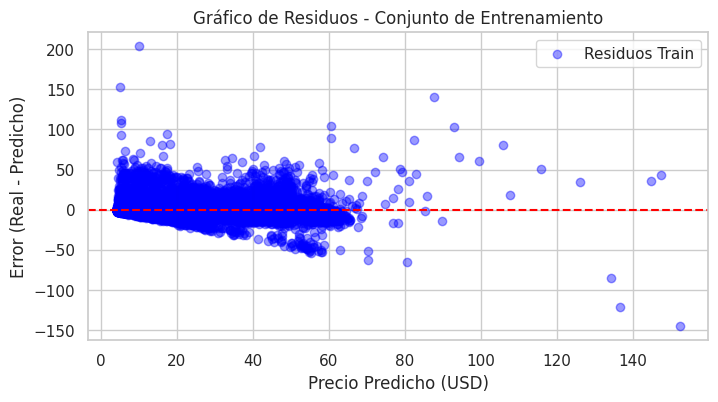

In [252]:
# Calculamos los residuos de Train
residuos_train = y_train_limpio - y_pred_train

plt.figure(figsize=(8, 4))
# Usamos un color distinto para Test, por ejemplo verde o púrpura
plt.scatter(y_pred_train, residuos_train, alpha=0.4, color='blue', label='Residuos Train')

plt.axhline(y=0, color='red', linestyle='--') # Línea de error cero
plt.title('Gráfico de Residuos - Conjunto de Entrenamiento')
plt.xlabel('Precio Predicho (USD)')
plt.ylabel('Error (Real - Predicho)')
plt.legend()
plt.show()

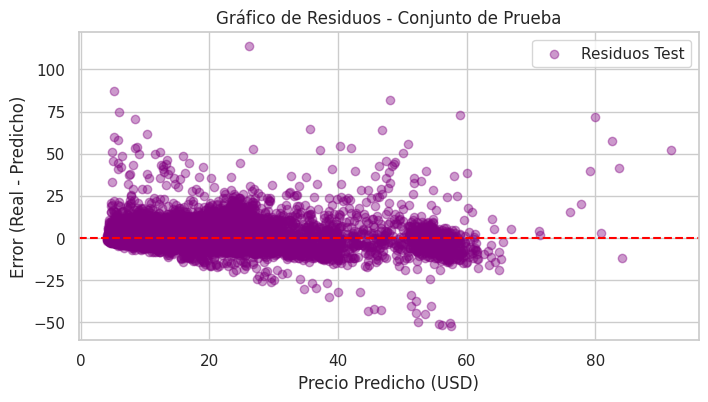

In [253]:
# Calculamos los residuos de Test
residuos_test = y_test_limpio - y_pred_test

plt.figure(figsize=(8, 4))
# Usamos un color distinto para Test, por ejemplo verde o púrpura
plt.scatter(y_pred_test, residuos_test, alpha=0.4, color='purple', label='Residuos Test')

plt.axhline(y=0, color='red', linestyle='--') # Línea de error cero
plt.title('Gráfico de Residuos - Conjunto de Prueba')
plt.xlabel('Precio Predicho (USD)')
plt.ylabel('Error (Real - Predicho)')
plt.legend()
plt.show()

La similitud de las distribuciones de los residuos entre ambos gráficos muestran visualmente lo que indicaban las métricas, el modelo no presenta sobreajuste.

El gráfico muestra una distribución concentrada alrededor del cero para valores hasta 60 USD, sin embargo a medida que aumenta el precio se observa mayor dispersión de residuos.

---
### Gradiente Descendiente Batch

In [254]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_test = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

---
#### Variación de Learning Rate

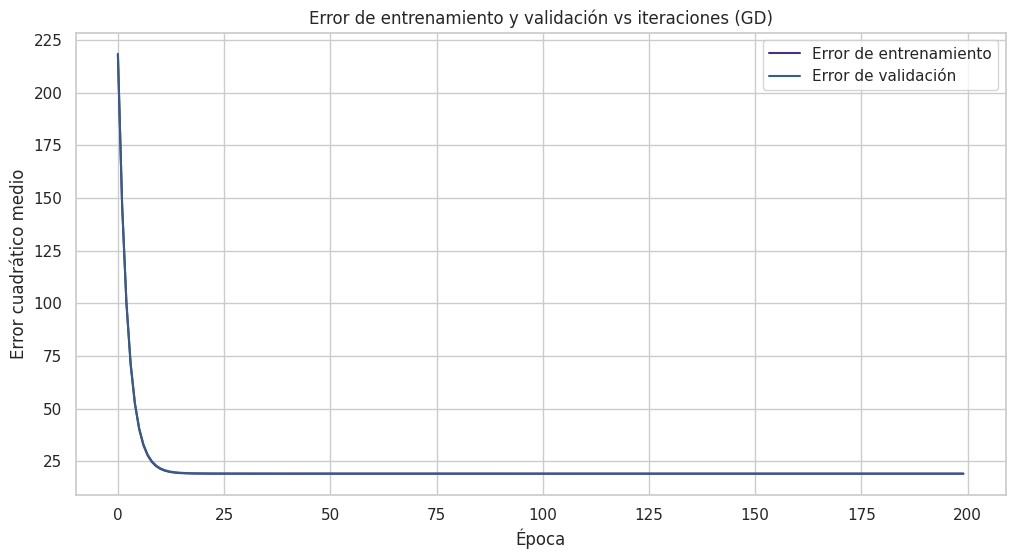

lr=0.1 | RMSE=4.3839 | R2=0.7915


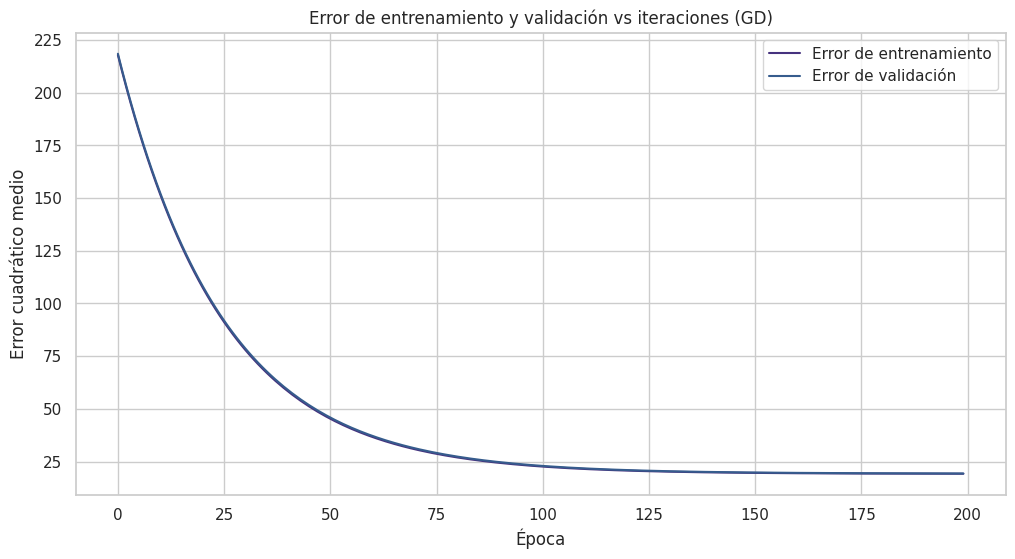

lr=0.01 | RMSE=4.3974 | R2=0.7903


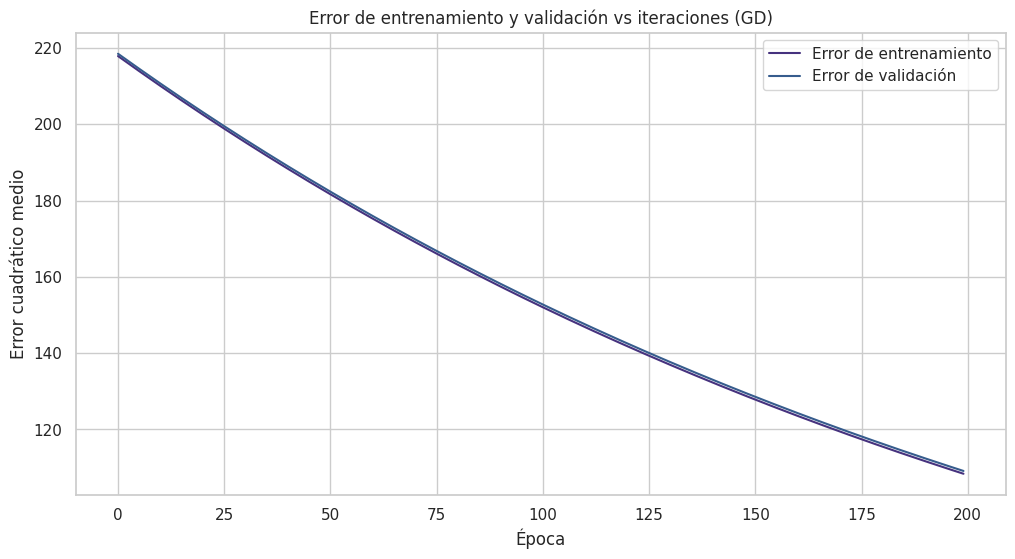

lr=0.001 | RMSE=10.4284 | R2=-0.1796


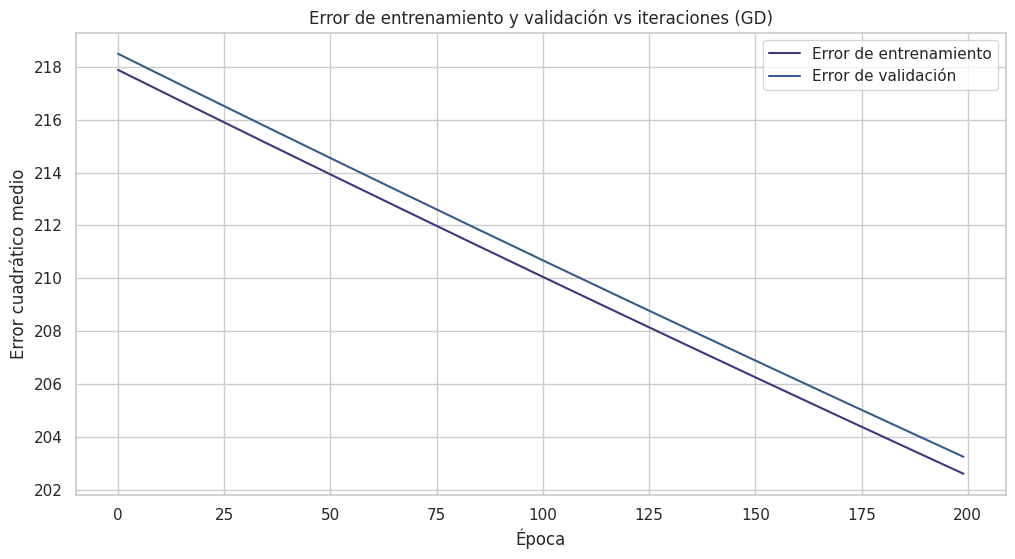

lr=0.0001 | RMSE=14.2536 | R2=-1.2037


In [255]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

for lr in learning_rates:
    np.random.seed(42)
    W = gradient_descent(X_train_scaled, y_train_limpio.values.reshape(-1,1),
                         X_test_scaled, y_test_limpio.values.reshape(-1,1),
                         lr=lr, epochs=200)
    X_test_ones = np.hstack((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))
    y_pred = np.matmul(X_test_ones, W).flatten()
    rmse = np.sqrt(mean_squared_error(y_test_limpio, y_pred))
    r2   = r2_score(y_test_limpio, y_pred)
    print(f"lr={lr} | RMSE={rmse:.4f} | R2={r2:.4f}")

---
#### Learning Rate óptimo

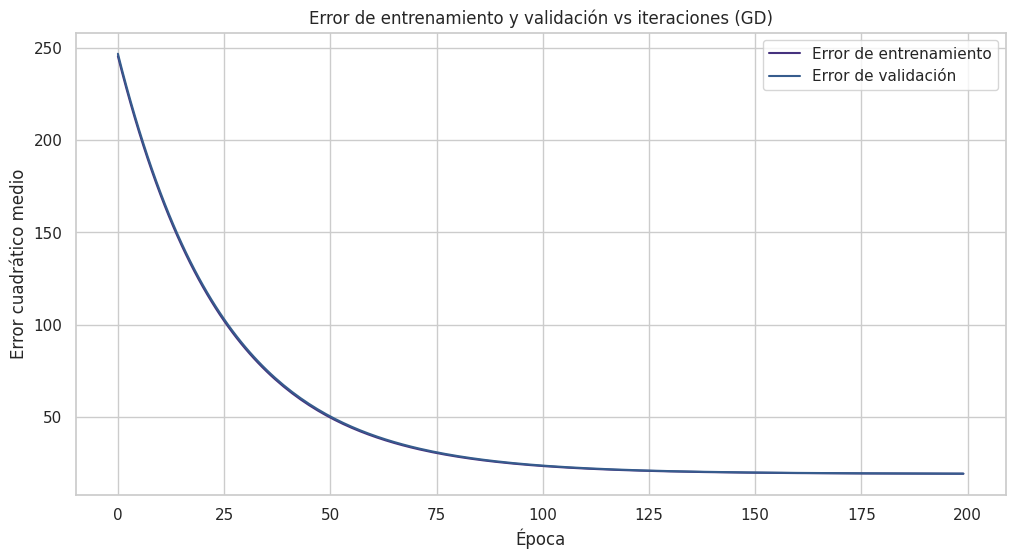

In [256]:
w_batch = gradient_descent(X_train_scaled, y_train_limpio.values.reshape(-1,1), X_test_scaled, y_test_limpio.values.reshape(-1,1), epochs=200, lr=0.01)

---
### Gradiente Descendiente Estocástico

In [257]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

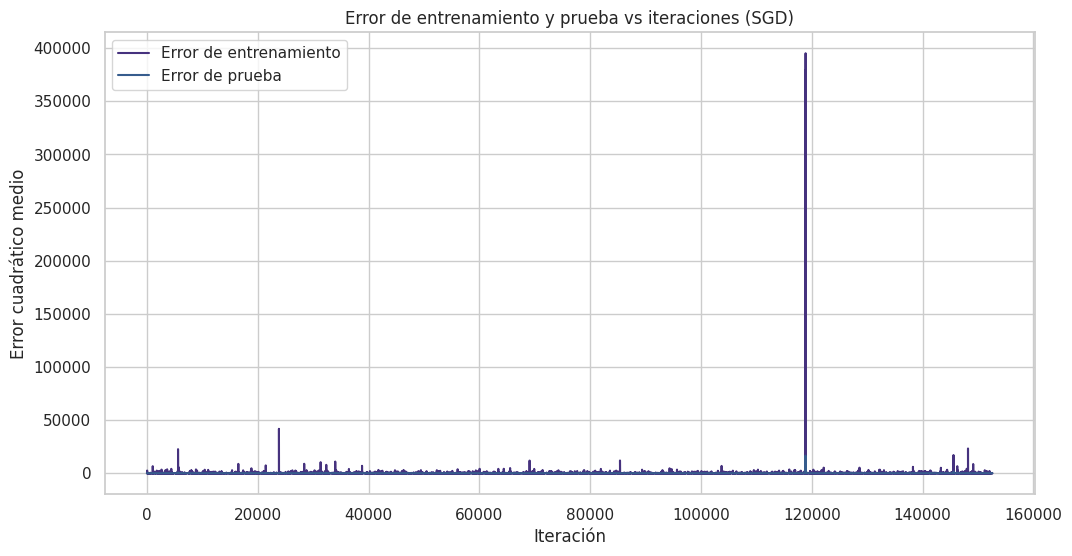

In [258]:
w_sgd = stochastic_gradient_descent(X_train_scaled, y_train_limpio.values.reshape(-1,1), X_test_scaled, y_test_limpio.values.reshape(-1,1), epochs=1, lr=0.01)

Se observa una alta volatilidad en el error de entrenamiento. Esto se debe a la naturaleza del algoritmo, que actualiza los pesos registro por registro, reaccionando violentamente a cada observación individual (ruido).

A pesar de los picos de error (causados por outliers en los datos), se observa que el error de prueba se mantiene bajo y estable, lo que indica que el modelo logra capturar la tendencia general a pesar de la inestabilidad del proceso de aprendizaje estocástico.

---
### Mini Batch

In [259]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

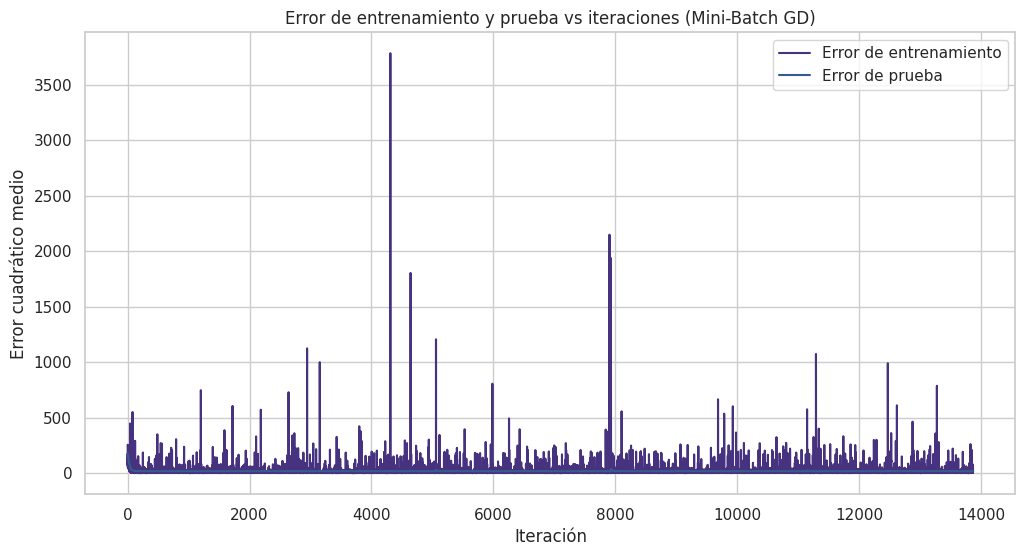

In [260]:
w_mini = mini_batch_gradient_descent(X_train_scaled, y_train_limpio.values.reshape(-1,1), X_test_scaled, y_test_limpio.values.reshape(-1,1), epochs=1)

---
#### Comparación Pesos de Modelos GD

In [261]:
# Creamos una tablita para comparar los pesos (W)
comparativa_w = pd.DataFrame({
    'Batch GD': w_batch.flatten(),
    'SGD': w_sgd.flatten(),
    'Mini-Batch': w_mini.flatten()
})

print("--- COMPARATIVA DE PESOS (W) ---")
print(comparativa_w)

--- COMPARATIVA DE PESOS (W) ---
   Batch GD     SGD  Mini-Batch
0   11.1631 11.0257     11.3442
1    8.3085  7.4063      8.3361
2    0.0828  0.4755      0.1002
3    0.0026  0.2700      0.2316
4   -0.4630  0.2117      0.1411
5   -0.3915  0.1362     -0.0174
6   -0.4052  0.0771      0.0843
7   -0.4068 -0.1673      0.1928
8   -0.5693 -0.2714     -0.2917
9   -0.5602 -0.1251     -0.0198


In [262]:
# Preparar datos
X_train_ones = np.hstack((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))
X_test_ones  = np.hstack((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))

# Predicciones de los tres métodos
y_pred_test_batch = np.matmul(X_test_ones, w_batch).flatten()
y_pred_test_sgd   = np.matmul(X_test_ones, w_sgd).flatten()
y_pred_test_mini  = np.matmul(X_test_ones, w_mini).flatten()

# Métricas
rmse_gd_batch = np.sqrt(mean_squared_error(y_test_limpio, y_pred_test_batch))
rmse_gd_sgd   = np.sqrt(mean_squared_error(y_test_limpio, y_pred_test_sgd))
rmse_gd_mini  = np.sqrt(mean_squared_error(y_test_limpio, y_pred_test_mini))

print("--- MÉTRICAS GRADIENTE DESCENDIENTE ---")
print(f"Método      | R²     | RMSE")
print(f"Batch GD    | {r2_score(y_test_limpio, y_pred_test_batch):.4f} | {rmse_gd_batch:.4f}")
print(f"SGD         | {r2_score(y_test_limpio, y_pred_test_sgd):.4f} | {rmse_gd_sgd:.4f}")
print(f"Mini-batch  | {r2_score(y_test_limpio, y_pred_test_mini):.4f} | {rmse_gd_mini:.4f}")

--- MÉTRICAS GRADIENTE DESCENDIENTE ---
Método      | R²     | RMSE
Batch GD    | 0.7881 | 4.4196
SGD         | 0.7722 | 4.5825
Mini-batch  | 0.7896 | 4.4045


In [263]:
# Preparar datos
X_train_ones = np.hstack((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))
X_test_ones = np.hstack((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))

# Predecir con los pesos
y_pred_train_gd = np.matmul(X_train_ones, w_batch)
y_pred_test_gd = np.matmul(X_test_ones, w_batch)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

metrics_gd = {
    "R2": [r2_score(y_train_limpio, y_pred_train_gd), r2_score(y_test_limpio, y_pred_test_gd)],
    "MAE": [mean_absolute_error(y_train_limpio, y_pred_train_gd), mean_absolute_error(y_test_limpio, y_pred_test_gd)],
    "RMSE": [np.sqrt(mean_squared_error(y_train_limpio, y_pred_train_gd)), np.sqrt(mean_squared_error(y_test_limpio, y_pred_test_gd))]
}

print("--- MÉTRICAS BATCH GD (FINAL) ---")
print(f"Métrica | Train  | Test")
print(f"R2      | {metrics_gd['R2'][0]:.4f} | {metrics_gd['R2'][1]:.4f}")
print(f"MAE     | {metrics_gd['MAE'][0]:.2f}   | {metrics_gd['MAE'][1]:.2f}")
print(f"RMSE    | {metrics_gd['RMSE'][0]:.2f}   | {metrics_gd['RMSE'][1]:.2f}")

--- MÉTRICAS BATCH GD (FINAL) ---
Métrica | Train  | Test
R2      | 0.7860 | 0.7881
MAE     | 2.47   | 2.48
RMSE    | 4.41   | 4.42


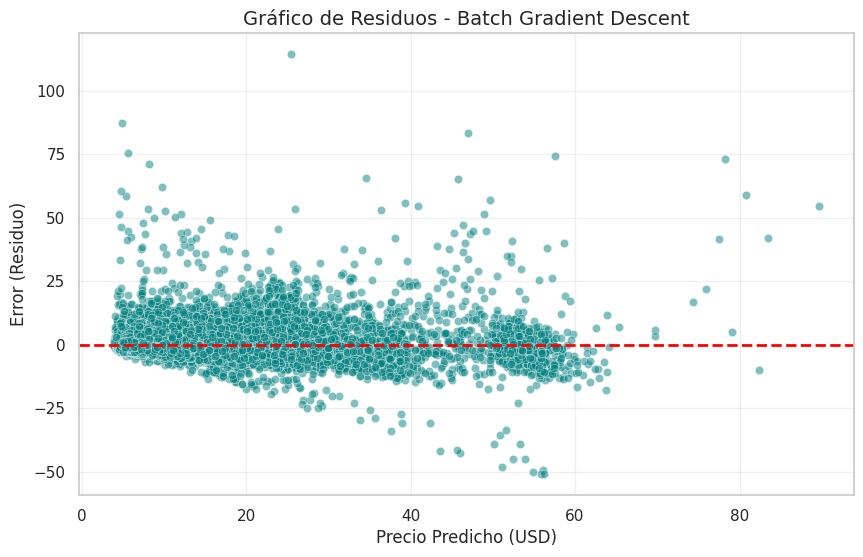

In [264]:
# Calculamos los residuos
# Aseguramos que ambos sean vectores planos para que no haya errores de forma
residuos_gd = y_test_limpio.values.flatten() - y_pred_test_batch.flatten()

# Graficamos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_test_batch.flatten(), y=residuos_gd, alpha=0.5, color='teal')

# Linea de referencia en cero
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Gráfico de Residuos - Batch Gradient Descent', fontsize=14)
plt.xlabel('Precio Predicho (USD)')
plt.ylabel('Error (Residuo)')
plt.grid(alpha=0.3)
plt.show()

---
### Regularización

In [265]:
# Calcula y devuelve métricas de evaluación de un modelo.
# recibe: Valores reales y Predicciones
# enterga: cuatro métricas de evaluación.
def eval_metrics(y, yhat):
    mse = mean_squared_error(y, yhat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, yhat)
    r2 = r2_score(y, yhat)
    return {"R2": r2, "RMSE": rmse, "MAE": mae}

---
#### Ridge

Mejor valor de alpha encontrado: 7.609496685459876
--- MÉTRICAS RIDGE ---
R2  Train: 0.7897 | Test: 0.7915
MAE Train: 2.47   | Test: 2.48
RMSE Train: 4.37  | Test: 4.38


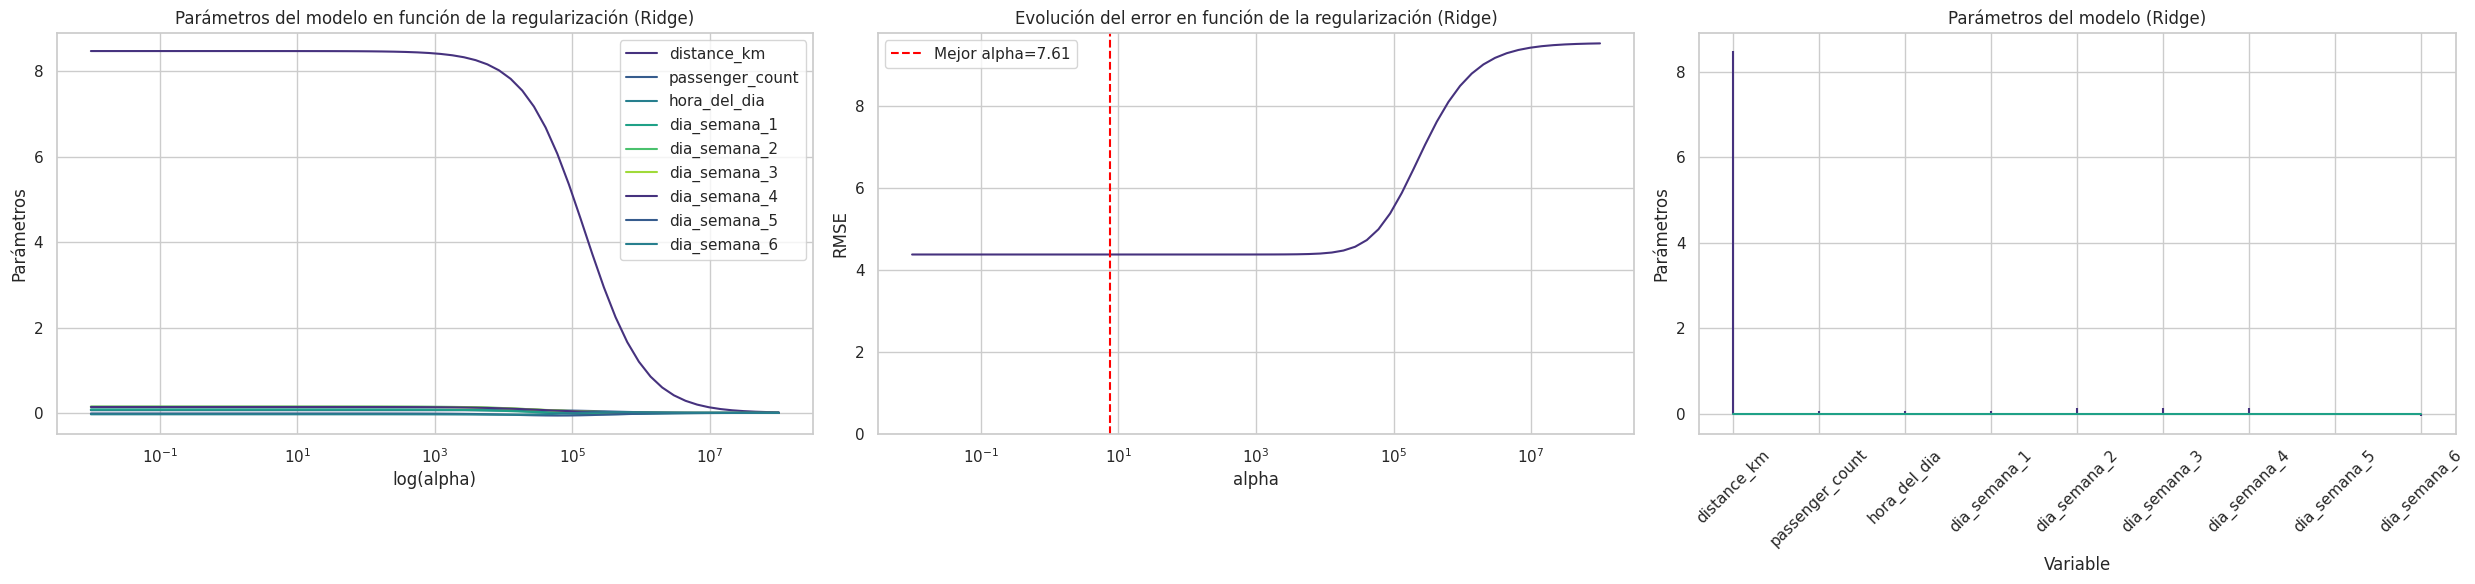

In [266]:
# Crear y entrenar el modelo Ridge con Cross-Validation
model_ridge = RidgeCV(
    alphas          = np.logspace(-2, 8, 60),
    fit_intercept   = True,
    store_cv_results = True
)
model_ridge.fit(X_train_scaled, y_train_limpio)

# Coeficientes en función de alpha
alphas_r = model_ridge.alphas
coefs_r  = []
for alpha in alphas_r:
    aux = Ridge(alpha=alpha)
    aux.fit(X_train_scaled, y_train_limpio)
    coefs_r.append(aux.coef_.flatten())

# Evolución del error de validación cruzada en función de alpha
mse_cv_r  = model_ridge.cv_results_.mean(axis=0)
rmse_cv_r = np.sqrt(mse_cv_r)

print(f"Mejor valor de alpha encontrado: {model_ridge.alpha_}")

# Coeficientes del modelo final
df_coef_ridge = pd.DataFrame({'predictor': X_train_limpio.columns, 'coef': model_ridge.coef_.flatten()})

# Predicciones
y_pred_test_ridge  = model_ridge.predict(X_test_scaled)
y_pred_train_ridge = model_ridge.predict(X_train_scaled)

# Metricas
rmse_ridge = np.sqrt(mean_squared_error(y_test_limpio, y_pred_test_ridge))
print(f"--- MÉTRICAS RIDGE ---")
print(f"R2  Train: {r2_score(y_train_limpio, y_pred_train_ridge):.4f} | Test: {r2_score(y_test_limpio, y_pred_test_ridge):.4f}")
print(f"MAE Train: {mean_absolute_error(y_train_limpio, y_pred_train_ridge):.2f}   | Test: {mean_absolute_error(y_test_limpio, y_pred_test_ridge):.2f}")
print(f"RMSE Train: {np.sqrt(mean_squared_error(y_train_limpio, y_pred_train_ridge)):.2f}  | Test: {rmse_ridge:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(25, 6))

# Gráfico 1: Coeficientes en función de alpha
axes[0].plot(alphas_r, coefs_r, label=list(X_train_limpio.columns))
axes[0].set_xscale('log')
axes[0].set_xlabel('log(alpha)')
axes[0].set_ylabel('Parámetros')
axes[0].set_title('Parámetros del modelo en función de la regularización (Ridge)')
axes[0].legend(loc='best')

# Gráfico 2: RMSE CV en función de alpha
axes[1].plot(model_ridge.alphas, rmse_cv_r)
axes[1].set_xscale('log')
axes[1].set_ylim([0, None])
axes[1].set_title('Evolución del error en función de la regularización (Ridge)')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('RMSE')
axes[1].axvline(model_ridge.alpha_, color='red', linestyle='--',
                label=f'Mejor alpha={model_ridge.alpha_:.2f}')
axes[1].legend()

# Gráfico 3: Coeficientes del modelo final
axes[2].stem(df_coef_ridge.predictor, df_coef_ridge.coef, markerfmt=' ')
axes[2].set_xlabel('Variable')
axes[2].set_ylabel('Parámetros')
axes[2].set_title('Parámetros del modelo (Ridge)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

En la salida se observa que el mejor alpha encontrado es de 7.61, lo que indica una penalización leve. El grpafico de la izquierda muestra la evolución de los coeficientes a medida que sube el alpha, la variable que desciende muy rápido presentaba mucho ruido.

El gráfico del medio muestra el mejor alpha obtenido.

El de la derecha muestra la variable que más peso tiene sobre el precio, en este caso la distancia.

En cuanto a las métricas, son casi iguales a las de linearRegression, y muestran un buen fit al ser similares entre train y test.

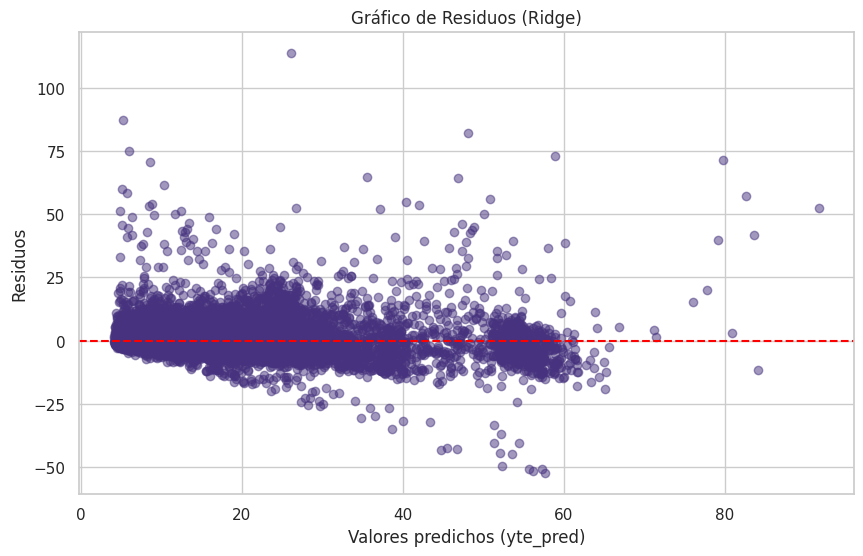

In [267]:
residuals_ridge = y_test_limpio - y_pred_test_ridge

# Gráficos de Residuos
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred_test_ridge, residuals_ridge, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_title('Gráfico de Residuos (Ridge)')
ax.set_xlabel('Valores predichos (yte_pred)')
ax.set_ylabel('Residuos');

La distribución de los residuos es muy similar al modelo lineal.

---
#### Lasso

Mejor valor de alpha encontrado: 0.001
Features con coeficiente ≠ 0:
         predictor    coef
0      distance_km  8.4773
1  passenger_count  0.0619
2     hora_del_dia  0.0741
3     dia_semana_1  0.0765
4     dia_semana_2  0.1458
5     dia_semana_3  0.1389
6     dia_semana_4  0.1351
7     dia_semana_5 -0.0148
8     dia_semana_6 -0.0341

--- MÉTRICAS LASSO ---
R2  Train: 0.7897 | Test: 0.7915
MAE Train: 2.47   | Test: 2.48
RMSE Train: 4.37  | Test: 4.38


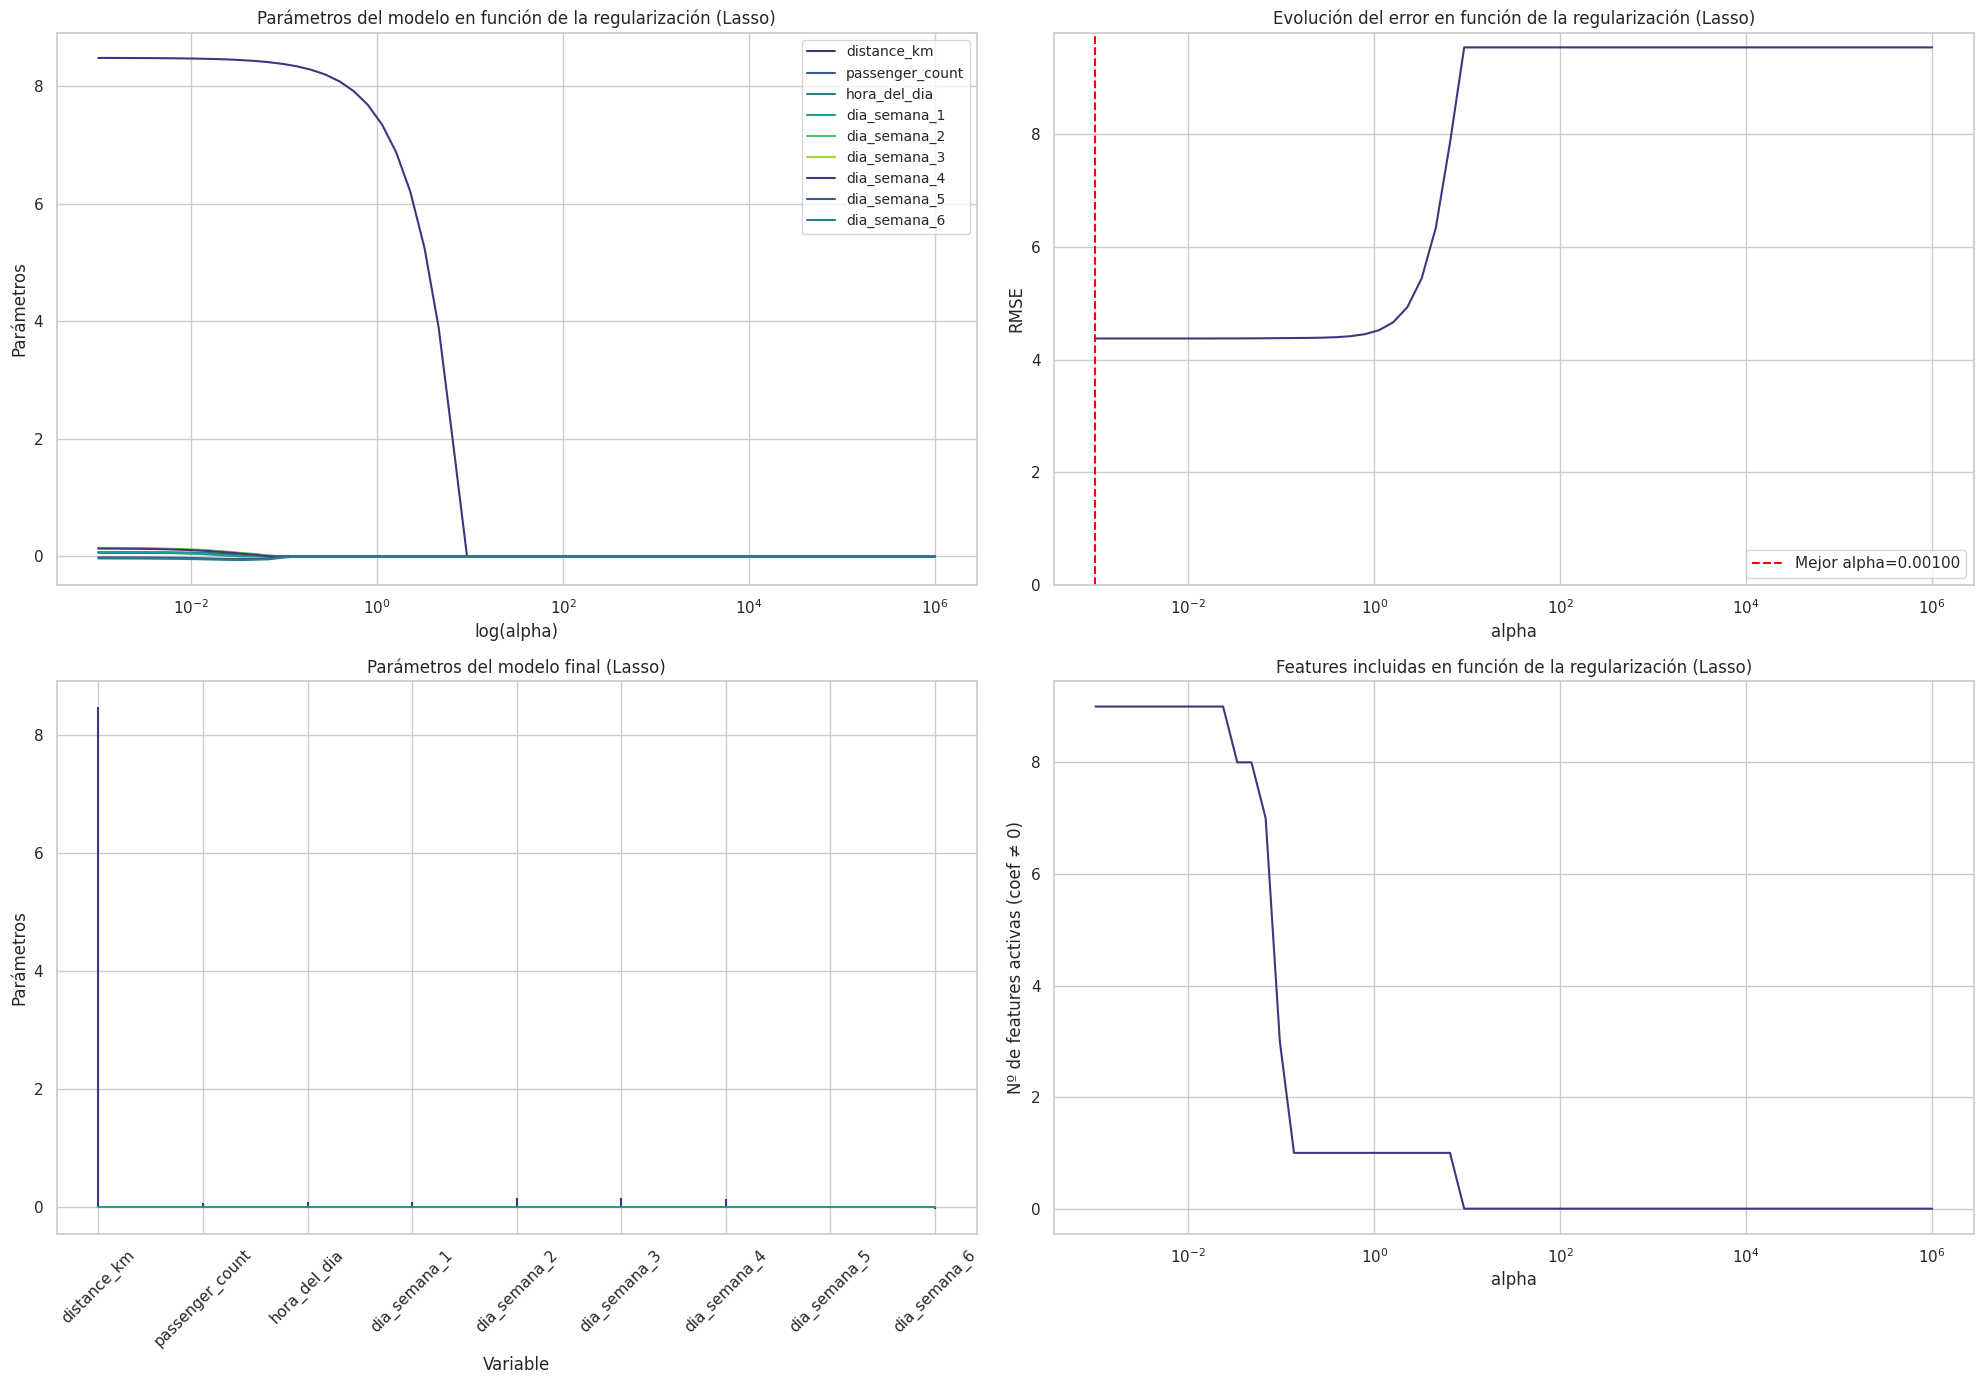

In [275]:
# Crear y entrenar el modelo Lasso con Cross-Validation
model_lasso = LassoCV(
    alphas = np.logspace(-3, 6, 60),
    cv     = 10
)
model_lasso.fit(X_train_scaled, y_train_limpio)

# Coeficientes en función de alpha
alphas_l = model_lasso.alphas_
coefs_l  = []
for alpha in alphas_l:
    aux = Lasso(alpha=alpha)
    aux.fit(X_train_scaled, y_train_limpio)
    coefs_l.append(aux.coef_.flatten())

# Número de features activas (coef != 0) en función de alpha
n_predictores = []
for alpha in alphas_l:
    aux = Lasso(alpha=alpha)
    aux.fit(X_train_scaled, y_train_limpio)
    n_predictores.append(np.sum(aux.coef_.flatten() != 0))

# Evolución del error de validación cruzada en función de alpha
mse_cv_l  = model_lasso.mse_path_.mean(axis=1)
rmse_cv_l = np.sqrt(mse_cv_l)

print(f"Mejor valor de alpha encontrado: {model_lasso.alpha_}")

# Coeficientes del modelo final
df_coef_lasso = pd.DataFrame({'predictor': X_train_limpio.columns, 'coef': model_lasso.coef_.flatten()})
print("Features con coeficiente ≠ 0:")
print(df_coef_lasso[df_coef_lasso.coef != 0])

# Predicciones
y_pred_test_lasso  = model_lasso.predict(X_test_scaled)
y_pred_train_lasso = model_lasso.predict(X_train_scaled)

# Métricas
rmse_lasso = np.sqrt(mean_squared_error(y_test_limpio, y_pred_test_lasso))
print(f"\n--- MÉTRICAS LASSO ---")
print(f"R2  Train: {r2_score(y_train_limpio, y_pred_train_lasso):.4f} | Test: {r2_score(y_test_limpio, y_pred_test_lasso):.4f}")
print(f"MAE Train: {mean_absolute_error(y_train_limpio, y_pred_train_lasso):.2f}   | Test: {mean_absolute_error(y_test_limpio, y_pred_test_lasso):.2f}")
print(f"RMSE Train: {np.sqrt(mean_squared_error(y_train_limpio, y_pred_train_lasso)):.2f}  | Test: {rmse_lasso:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Gráfico 1: Coeficientes en función de alpha
axes[0, 0].plot(alphas_l, coefs_l, label=list(X_train_limpio.columns))
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('log(alpha)')
axes[0, 0].set_ylabel('Parámetros')
axes[0, 0].set_title('Parámetros del modelo en función de la regularización (Lasso)')
axes[0, 0].legend(loc='best', fontsize='small')

# Gráfico 2: RMSE CV en función de alpha
axes[0, 1].plot(model_lasso.alphas_, rmse_cv_l)
axes[0, 1].set_xscale('log')
axes[0, 1].set_ylim([0, None])
axes[0, 1].set_title('Evolución del error en función de la regularización (Lasso)')
axes[0, 1].set_xlabel('alpha')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].axvline(model_lasso.alpha_, color='red', linestyle='--',
                   label=f'Mejor alpha={model_lasso.alpha_:.5f}')
axes[0, 1].legend()

# Gráfico 3: Coeficientes del modelo final
axes[1, 0].stem(df_coef_lasso.predictor, df_coef_lasso.coef, markerfmt=' ')
axes[1, 0].set_xlabel('Variable')
axes[1, 0].set_ylabel('Parámetros')
axes[1, 0].set_title('Parámetros del modelo final (Lasso)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Gráfico 4: Features activas en función de alpha
axes[1, 1].plot(alphas_l, n_predictores)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('alpha')
axes[1, 1].set_ylabel('Nº de features activas (coef ≠ 0)')
axes[1, 1].set_title('Features incluidas en función de la regularización (Lasso)')

ax.set_xlabel('RMSE (Error Promedio en USD)', fontsize=12)
ax.set_ylabel('Modelo Predictivo', fontsize=12)
ax.set_title('Comparación de Modelos según RMSE en Set de Prueba', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

El análisis de las métricas en Lasso es igual al de los modelos anteriores.

Lasso obtiene un alpha de 0.001 lo cual indica que el modelo no necesita eliminar variables.

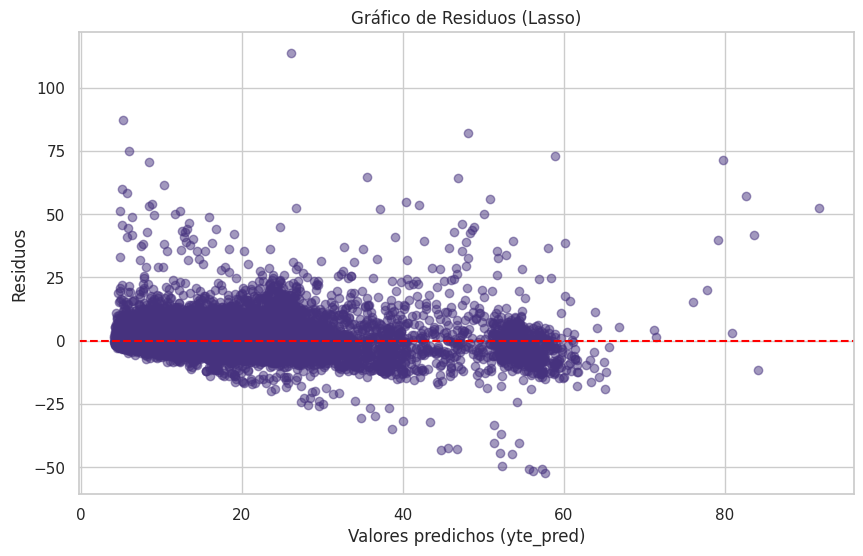

In [269]:
residuals_lasso = y_test_limpio - y_pred_test_lasso

# Gráficos de Residuos
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred_test_lasso, residuals_lasso, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_title('Gráfico de Residuos (Lasso)')
ax.set_xlabel('Valores predichos (yte_pred)')
ax.set_ylabel('Residuos');

El gráfico de residuos obtenido en Lasso es muy similar a los modelos anteriores.

---
#### Elastic Net

     l1_ratio  alphas  mse_cv  rmse_cv
359    0.9500  0.0100 19.1365   4.3745
419    0.9900  0.0100 19.1365   4.3745
299    0.9000  0.0100 19.1365   4.3745
239    0.7000  0.0100 19.1369   4.3746
179    0.5000  0.0100 19.1378   4.3747
Mejor valor de alpha encontrado: 0.01
Mejor valor de l1_ratio encontrado: 0.95

--- MÉTRICAS ELASTICNET ---
R2  Train: 0.7896 | Test: 0.7915
MAE Train: 2.47   | Test: 2.48
RMSE Train: 4.37  | Test: 4.38


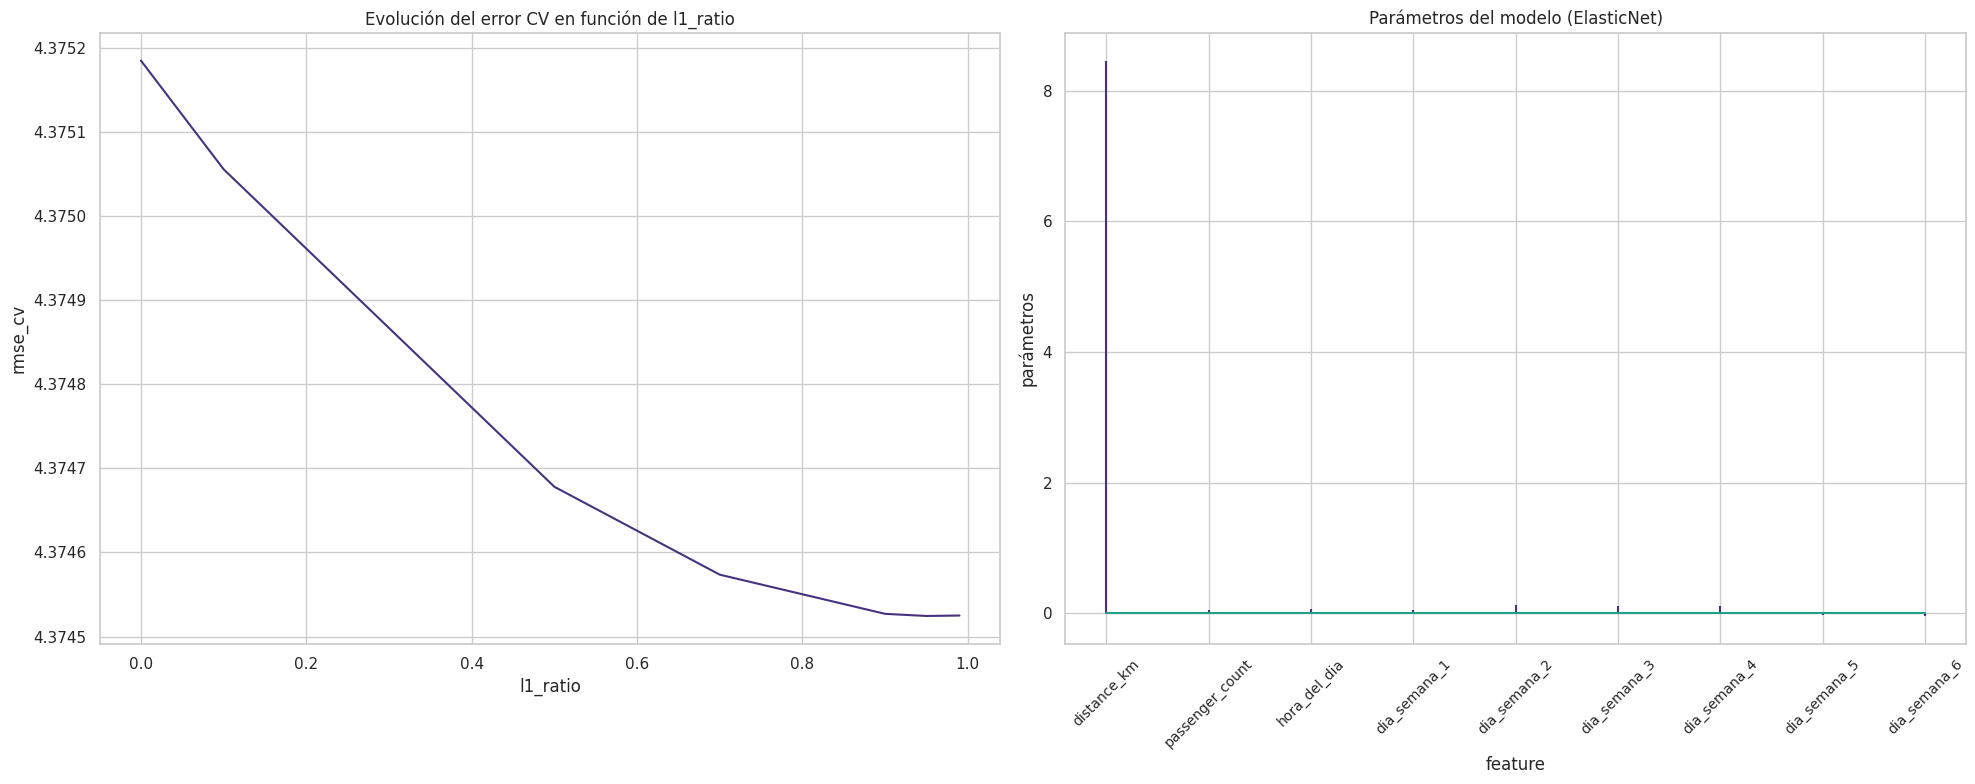

In [270]:
model_en = ElasticNetCV(
    l1_ratio = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    alphas   = np.logspace(-2, 8, 60),
    cv       = 10
)
model_en.fit(X_train_scaled, y_train_limpio)

# Error medio de las 10 particiones por cada valor de alpha y l1_ratio
mean_error_cv = model_en.mse_path_.mean(axis=2)

df_resultados_cv = pd.DataFrame(
    data    = mean_error_cv.flatten(),
    index   = pd.MultiIndex.from_product(
                  iterables = [model_en.l1_ratio, model_en.alphas_],
                  names     = ['l1_ratio', 'alphas']
              ),
    columns = ["mse_cv"]
)
df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending=True)
print(df_resultados_cv.head())

print(f"Mejor valor de alpha encontrado: {model_en.alpha_}")
print(f"Mejor valor de l1_ratio encontrado: {model_en.l1_ratio_}")

# Coeficientes del modelo final
df_coef_en = pd.DataFrame({'predictor': X_train_limpio.columns, 'coef': model_en.coef_.flatten()})

# Predicciones
y_pred_train_en = model_en.predict(X_train_scaled)
y_pred_test_en  = model_en.predict(X_test_scaled)

# Métricas
rmse_en = np.sqrt(mean_squared_error(y_test_limpio, y_pred_test_en))
print(f"\n--- MÉTRICAS ELASTICNET ---")
print(f"R2  Train: {r2_score(y_train_limpio, y_pred_train_en):.4f} | Test: {r2_score(y_test_limpio, y_pred_test_en):.4f}")
print(f"MAE Train: {mean_absolute_error(y_train_limpio, y_pred_train_en):.2f}   | Test: {mean_absolute_error(y_test_limpio, y_pred_test_en):.2f}")
print(f"RMSE Train: {np.sqrt(mean_squared_error(y_train_limpio, y_pred_train_en)):.2f}  | Test: {rmse_en:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Evolución del error CV en función de l1_ratio
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax=axes[0])
axes[0].set_title('Evolución del error CV en función de l1_ratio')
axes[0].set_xlabel('l1_ratio')
axes[0].set_ylabel('rmse_cv')

# Gráfico 2: Parámetros del modelo
axes[1].stem(df_coef_en.predictor, df_coef_en.coef, markerfmt=' ')
axes[1].set_title('Parámetros del modelo (ElasticNet)')
axes[1].set_xlabel('feature')
axes[1].set_ylabel('parámetros')
axes[1].tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout()
plt.show()

Las métricas de Elastic Net son prácticamente idénticas a las métricas de los modelos anteriores.

Al arrojar un l1_ratio de 0.95 el modelo indica que el 95% de la penalización es tipo Lasso. En el gráfico de la izquierda se ve que mientras el l1_ratio se acerca a 1, el error disminuye.

El alpha obtenido de 0.01 indica que al igual que antes, el modelo no necesita un castigo tan alto para funcionar bien.

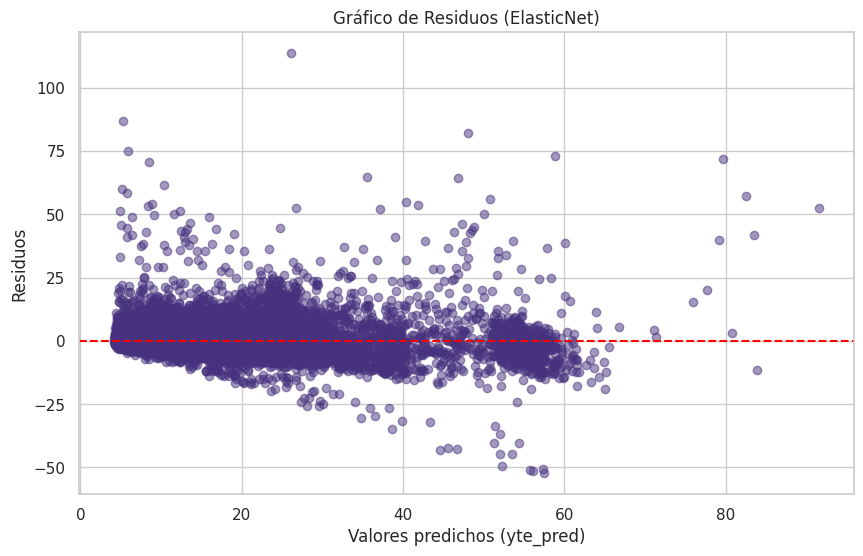

In [271]:
residuals_elastic = y_test_limpio - y_pred_test_en

# Gráficos de Residuos
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred_test_en, residuals_elastic, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_title('Gráfico de Residuos (ElasticNet)')
ax.set_xlabel('Valores predichos (yte_pred)')
ax.set_ylabel('Residuos');

---
#### Conclusiones de Modelos

Luego de comparar las métricas de los modelos entre sí y los gráficos de residuos, se considera que el fitting obtenido es bueno, ya que el R2 es sólido para datos desconocidos. También es muy importante la poca diferencia entre las métricas de entrenamiento y prueba, para demostrar que el modelo generaliza bien ante datos desconocidos.

En cuanto a Regularización, al ser bajo el alpha obtenido en Ridge y Lasso, se puede concluir que el modelo base era bastante bueno al no necesitar penalizaciones muy altas sobre los pesos. ElasticNet confirma con el l1_ratio que el modelo prefiere el estilo Lasso.

Sobre los resultados obtenidos en Gradiente Descendiente, se puede concluir que los tres métodos convergieron a métricas similares. El hecho de que el descenso manual coincida con los resultados de la regresión lineal confirma que el aprendizaje fue correcto y que los parámetros elegidos fueron adecuados.

---
## Optimización de Hiperparámetros

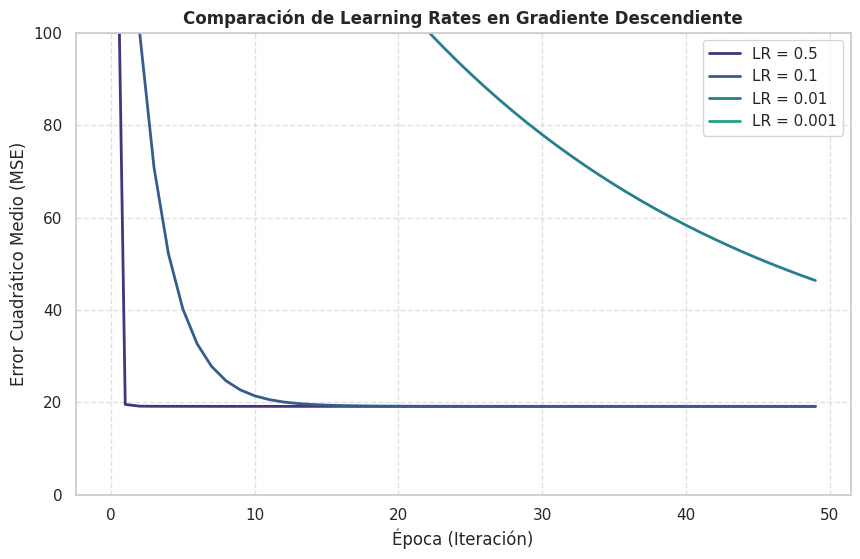

In [272]:
learning_rates_test = [0.5, 0.1, 0.01, 0.001]
iteraciones_test = 50

plt.figure(figsize=(10, 6))

n_train = X_train_scaled.shape[0]
X_train_ones = np.hstack((np.ones((n_train, 1)), X_train_scaled))
y_train_vec = y_train_limpio.values.reshape(-1, 1)

# Probamos cada learning rate y guardamos sus errores
for lr in learning_rates_test:
    np.random.seed(42)
    m_cols = X_train_scaled.shape[1]
    W_test = np.random.randn(m_cols + 1).reshape(-1, 1)

    errores = []
    for _ in range(iteraciones_test):
        prediccion = np.matmul(X_train_ones, W_test)
        error = y_train_vec - prediccion
        mse = np.mean(error ** 2)
        errores.append(mse)

        # Si el error explota, dejamos de calcular para ese LR
        if mse > 500 or np.isnan(mse) or np.isinf(mse):
            break

        gradiente = -2/n_train * np.matmul(X_train_ones.T, error)
        W_test = W_test - (lr * gradiente)

    plt.plot(errores, label=f'LR = {lr}', linewidth=2)

# grafico
plt.title('Comparación de Learning Rates en Gradiente Descendiente', fontweight='bold')
plt.xlabel('Época (Iteración)')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

En la imagen se observa que un learning rate excesivo hace que el error se dispare inmediatamente, demostrando cómo el algoritmo diverge y falla al buscar el minimo. Por el contrario, los valores de 0.1 y 0.01 logran una convergencia rápida y estable, mientras que el 0.001 desciende de manera demasiado lenta.

---
## Comparación de Modelos

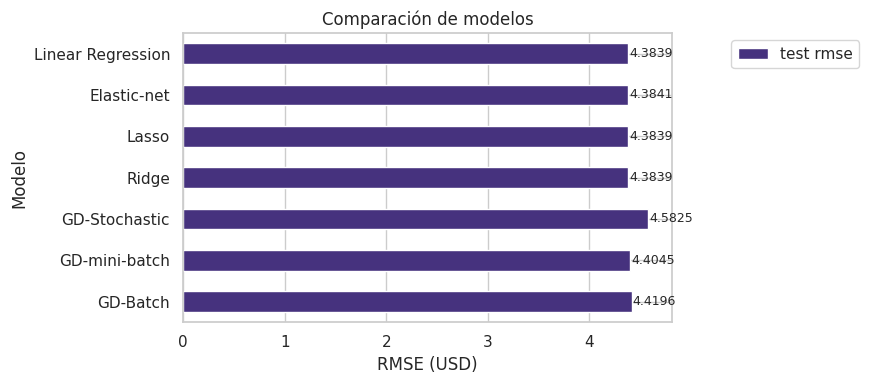

In [273]:
df_comparacion = pd.DataFrame({
                    'modelo': ['GD-Batch','GD-mini-batch','GD-Stochastic', 'Ridge', 'Lasso', 'Elastic-net','Linear Regression'],
                    'test rmse': [rmse_gd_batch, rmse_gd_mini , rmse_gd_sgd , rmse_ridge, rmse_lasso, rmse_en,rmse_test]
                 })

fig, ax = plt.subplots(figsize=(10, 4))
df_comparacion.set_index('modelo')['test rmse'].plot(kind='barh', ax=ax)

# Agregar valores al final de cada barra
for i, v in enumerate(df_comparacion['test rmse']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
ax.set_xlabel('RMSE (USD)')
ax.set_ylabel('Modelo')
ax.set_title('Comparación de modelos')
plt.tight_layout()
plt.show()

Se optó por RMSE para comparar modelos ya que se expresa en el valor de la variable (USD) y penaliza con mayor fuerza a los outliers. 

Observando el gráfico se ve que el RMSE es muy similar para todos los modelos, siendo los de Lasso, Ridge, Linear Regression y Elastic Net los más bajos. Es importante notar que si bien la regresión lineal tiene el mismo error que los métodos de Ridge y Lasso, estos dos ofrecen mayor robustez al penalizar los pesos. 

---
## Conclusiones

El objetivo del trabajo fue construir un modelo predictivo de tarifas de Uber. A lo largo del análisis se trabajó con un dataset de aproximadamente 190.000 viajes, evaluando distintos modelos de regresión.

Se realizó el split train/test de antemano para evitar la fuga de datos. Durante el proceso, comprobamos que el escalado de datos (StandardScaler) y la limpieza de outliers (filtrando distancias anómalas y excesos de pasajeros) fueron la clave para que el Gradiente Descendiente no fallara y pudiera converger correctamente.
Nuestro modelo base logró un R² de 0.79 y un RMSE de 4.38 USD. Esto significa que el modelo explica el 79% del precio de los viajes basándose casi totalmente en la distancia recorrida (distance_km), siendo esta la variable más determinante con diferencia.
La aplicación de regularización (Ridge, Lasso y ElasticNet) arrojó resultados idénticos al modelo base, con hiperparámetros alpha muy cercanos a cero. Esto nos dio seguridad estadística al confirmarnos que nuestro modelo no sufre de overfitting gracias a la buena limpieza inicial. Demostramos que no hace falta un modelo demasiado complejo; con una regresión lineal bien ajustada y regularizada, el sistema es confiable para predecir precios sobre viajes nuevos.